# 🛡️ Fake Job Detection 
### By: Sumersing Patil | B.Tech (AI) | Data Analyst & ML Enthusiast

---
**Project Goal:** Detect fraudulent job postings using NLP, Machine Learning, and advanced analytics.  
**Dataset:** Real or Fake Job Posting Prediction (17,880 records, 866 fake = 4.84%)  
**Stack:** Python · Pandas · Scikit-learn · SHAP · Matplotlib · Seaborn · WordCloud · SQL (SQLite)

---
## 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Overview](#2)
3. [Feature Engineering](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [SQL Analysis (SQLite)](#5)
6. [Machine Learning – Model Training](#6)
7. [Model Evaluation & Comparison](#7)
8. [Explainability (SHAP)](#8)
9. [Business Insights Summary](#9)
10. [Export Artifacts](#10)


## 1️⃣ Setup & Imports <a id='1'></a>

In [1]:
# Install required libraries (run once)
import subprocess, sys

pkgs = [
    "wordcloud", "shap", "imbalanced-learn", "scikit-learn",
    "seaborn", "matplotlib", "pandas", "numpy",
    "google-generativeai", "pdfplumber", "python-docx"
]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True)

print("✅ All libraries ready!")


✅ All libraries ready!


In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import re
import string
import sqlite3
import json
import pickle
from datetime import datetime

warnings.filterwarnings('ignore')

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score,
                              precision_recall_curve, ConfusionMatrixDisplay)
from scipy.sparse import hstack, csr_matrix

# ── SMOTE (class imbalance) ────────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✅ SMOTE available (imbalanced-learn)")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  SMOTE not available – run: pip install imbalanced-learn")

# Visualisation
from wordcloud import WordCloud

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available – skipping explainability section")

# ── Gemini AI ────────────────────────────────────────────────────────────────
try:
    import google.generativeai as genai
    GEMINI_AVAILABLE = True
    print("✅ Gemini AI (google-generativeai) available")
except ImportError:
    GEMINI_AVAILABLE = False
    print("⚠️  Gemini not available – run: pip install google-generativeai")

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = "Fake Job Postings.csv"
OUTPUT_DIR  = "outputs"
MODELS_DIR  = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
COLORS = {'fake': '#E74C3C', 'real': '#2ECC71', 'neutral': '#3498DB', 'bg': '#F8F9FA'}
print("✅ Setup complete –", datetime.now().strftime("%Y-%m-%d %H:%M"))


✅ SMOTE available (imbalanced-learn)
✅ Gemini AI (google-generativeai) available
✅ Setup complete – 2026-03-11 12:00


## 2️⃣ Data Loading & Overview <a id='2'></a>

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv("Fake Job Postings.csv")
print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🚨 Fraudulent Jobs : {df['fraudulent'].sum():,}  ({df['fraudulent'].mean()*100:.2f}%)")
print(f"✅ Legitimate Jobs : {(df['fraudulent']==0).sum():,}  ({(df['fraudulent']==0).mean()*100:.2f}%)")
df.head(3)

📊 Dataset Shape: 17,880 rows × 18 columns
🚨 Fraudulent Jobs : 866  (4.84%)
✅ Legitimate Jobs : 17,014  (95.16%)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [4]:
# ── Data Types & Missing Values ────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=" * 45)
print("MISSING VALUES SUMMARY")
print("=" * 45)
print(missing_df.to_string())

MISSING VALUES SUMMARY
                     Missing Count  Missing %
salary_range                 15012      83.96
department                   11547      64.58
required_education            8105      45.33
benefits                      7212      40.34
required_experience           7050      39.43
function                      6455      36.10
industry                      4903      27.42
employment_type               3471      19.41
company_profile               3308      18.50
requirements                  2696      15.08
location                       346       1.94
description                      1       0.01


In [5]:
# ── Statistical Summary ───────────────────────────────────────────────────
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,17880.0,NaN,NaN,NaN,8940.5,5161.655742,1.0,4470.75,8940.5,13410.25,17880.0
title,17880,11231,English Teacher Abroad,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,17534,3105,"GB, LND, London",718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,6333,1337,Sales,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,2868,874,0-0,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,14572,1709,We help teachers get safe &amp; secure jobs ab...,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,17879,14801,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,15184,11967,University degree required. TEFL / TESOL / CEL...,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,10668,6204,See job description,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,17880.0,NaN,NaN,NaN,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0


## 3️⃣ Feature Engineering <a id='3'></a>

In [6]:
# ── Text Preprocessing ───────────────────────────────────────────────────
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # normalise whitespace
    return text

URGENCY_WORDS = [
    'urgent', 'immediate', 'asap', 'hurry', 'limited', 'act now', 'no experience',
    'work from home', 'earn money', 'easy money', 'guaranteed', 'weekly pay',
    'quick money', 'high pay', 'bonus', '100%', 'free training', 'daily pay'
]

def has_urgency(text):
    if pd.isna(text): return 0
    t = str(text).lower()
    return int(any(w in t for w in URGENCY_WORDS))

# ── Build Feature Columns ─────────────────────────────────────────────────
df['has_salary']          = df['salary_range'].notna().astype(int)
df['has_company_profile'] = df['company_profile'].notna().astype(int)
df['has_requirements']    = df['requirements'].notna().astype(int)
df['has_benefits']        = df['benefits'].notna().astype(int)
df['has_department']      = df['department'].notna().astype(int)
df['has_company_logo']    = df['has_company_logo'].fillna(0).astype(int)
df['has_questions']       = df['has_questions'].fillna(0).astype(int)
df['telecommuting']       = df['telecommuting'].fillna(0).astype(int)

df['desc_length']         = df['description'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['req_length']          = df['requirements'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['title_length']        = df['title'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

df['has_urgency_words']   = (df['title'].fillna('') + ' ' + df['description'].fillna('')).apply(has_urgency)

df['profile_completeness'] = (df['has_salary'] + df['has_company_profile'] +
                               df['has_requirements'] + df['has_benefits'] +
                               df['has_department'] + df['has_company_logo'])

df['country'] = df['location'].apply(
    lambda x: str(x).split(',')[-1].strip() if pd.notna(x) else 'Unknown'
)

# ── Combined Text for NLP ─────────────────────────────────────────────────
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
).apply(clean_text)

print(f"✅ Feature engineering done! Total features created: 14 new columns")
print(f"📝 Combined text sample (first 200 chars):")
print(df['combined_text'].iloc[0][:200])
df[['has_salary','has_company_profile','has_requirements','desc_length',
    'has_urgency_words','profile_completeness','fraudulent']].describe()

✅ Feature engineering done! Total features created: 14 new columns
📝 Combined text sample (first 200 chars):
marketing intern we re food and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top 


,has_salary,has_company_profile,has_requirements,desc_length,has_urgency_words,profile_completeness,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,0.160403,0.814989,0.849217,1218.004418,0.168624,3.570749,0.048434
std,0.366989,0.388317,0.357847,894.828620,0.374430,1.366595,0.214688
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,607.000000,0.000000,3.000000,0.000000
50%,0.000000,1.000000,1.000000,1017.000000,0.000000,4.000000,0.000000
75%,0.000000,1.000000,1.000000,1586.000000,0.000000,5.000000,0.000000
max,1.000000,1.000000,1.000000,14907.000000,1.000000,6.000000,1.000000


## 4️⃣ Exploratory Data Analysis (EDA) <a id='4'></a>

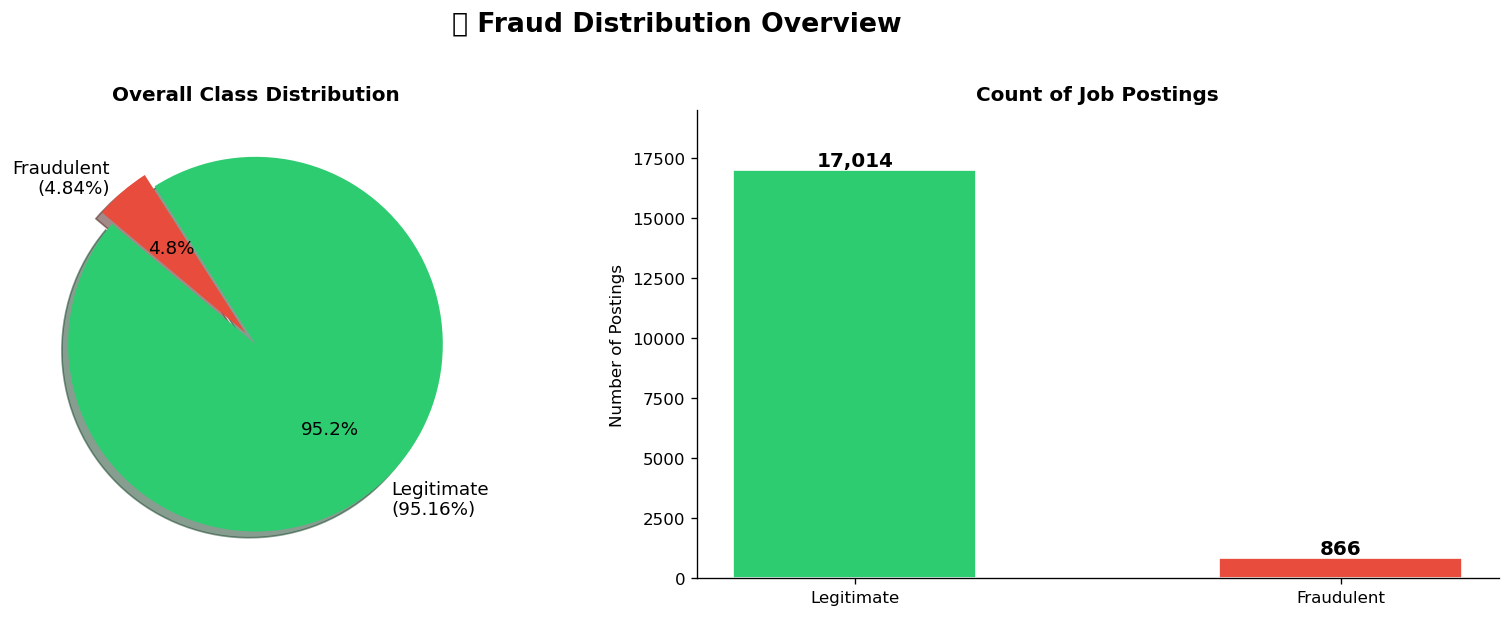

💾 Saved: 01_fraud_distribution.png


In [7]:
# ── Chart 1: Fraud Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Fraud Distribution Overview', fontsize=16, fontweight='bold', y=1.02)

# Pie chart
labels   = ['Legitimate\n(95.16%)', 'Fraudulent\n(4.84%)']
sizes    = [df['fraudulent'].value_counts()[0], df['fraudulent'].value_counts()[1]]
explode  = (0, 0.08)
colors   = [COLORS['real'], COLORS['fake']]
axes[0].pie(sizes, labels=labels, explode=explode, colors=colors,
            autopct='%1.1f%%', startangle=140, shadow=True,
            textprops={'fontsize': 11})
axes[0].set_title('Overall Class Distribution', fontweight='bold')

# Count bar
fraud_counts = df['fraudulent'].value_counts()
bars = axes[1].bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
                   color=[COLORS['real'], COLORS['fake']], edgecolor='white', width=0.5)
for bar, val in zip(bars, fraud_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Count of Job Postings', fontweight='bold')
axes[1].set_ylabel('Number of Postings')
axes[1].set_ylim(0, 19500)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_fraud_distribution.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 01_fraud_distribution.png")

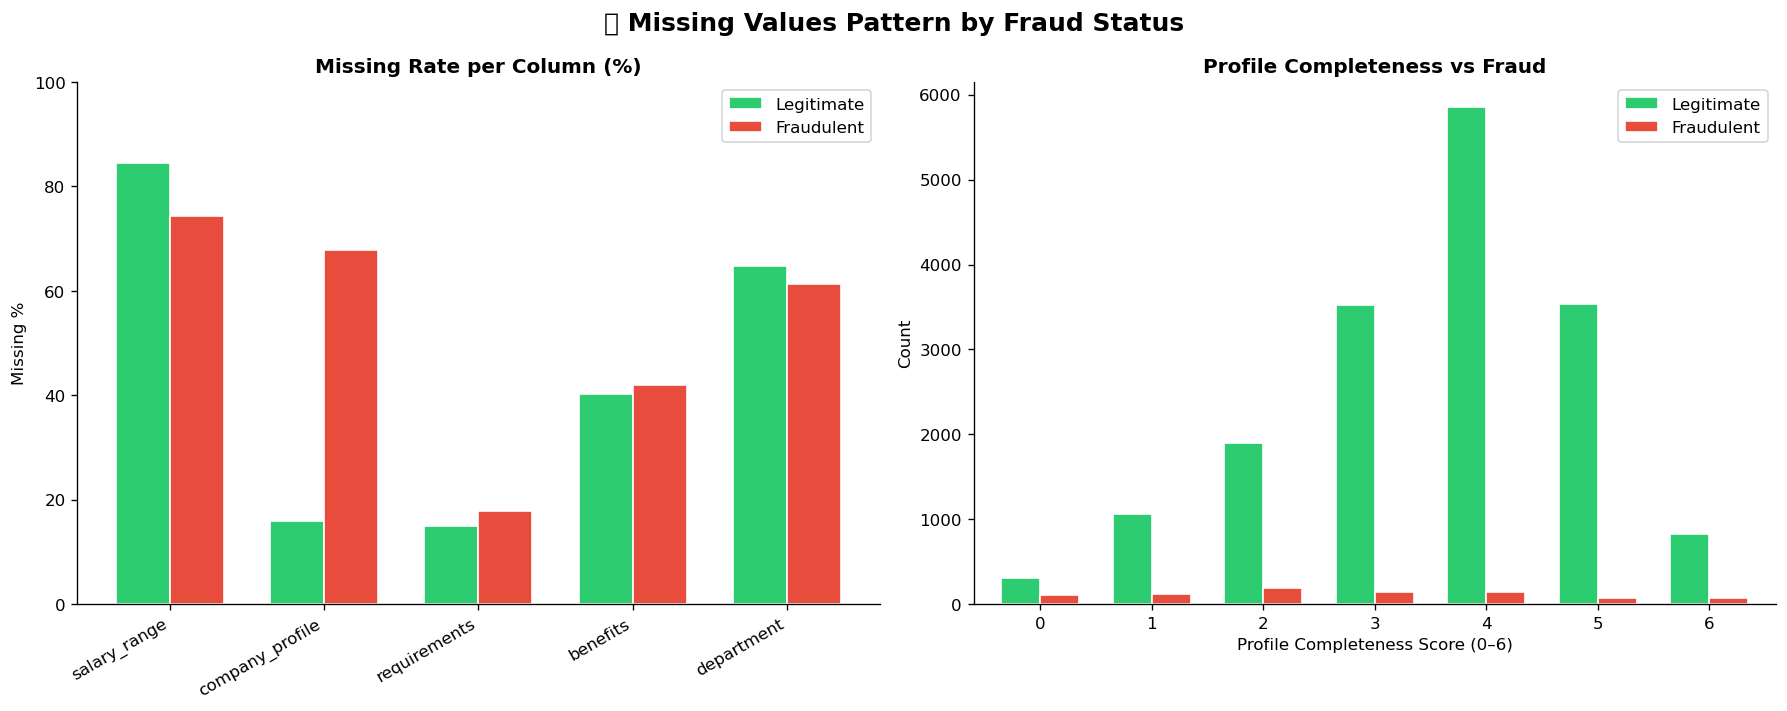

💾 Saved: 02_missing_values_fraud.png


In [8]:
# ── Chart 2: Missing Values by Fraud Status ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🔍 Missing Values Pattern by Fraud Status', fontsize=15, fontweight='bold')

miss_cols = ['salary_range', 'company_profile', 'requirements', 'benefits', 'department']
fraud_g   = df.groupby('fraudulent')[miss_cols].apply(lambda x: x.isnull().mean() * 100)
fraud_g.index = ['Legitimate', 'Fraudulent']

fraud_g.T.plot(kind='bar', ax=axes[0], color=[COLORS['real'], COLORS['fake']],
               edgecolor='white', width=0.7)
axes[0].set_title('Missing Rate per Column (%)', fontweight='bold')
axes[0].set_ylabel('Missing %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 100)

# Profile completeness
pc = df.groupby(['profile_completeness', 'fraudulent']).size().unstack(fill_value=0)
pc.columns = ['Legitimate', 'Fraudulent']
pc.plot(kind='bar', ax=axes[1], color=[COLORS['real'], COLORS['fake']],
        edgecolor='white', width=0.7)
axes[1].set_title('Profile Completeness vs Fraud', fontweight='bold')
axes[1].set_xlabel('Profile Completeness Score (0–6)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_missing_values_fraud.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 02_missing_values_fraud.png")

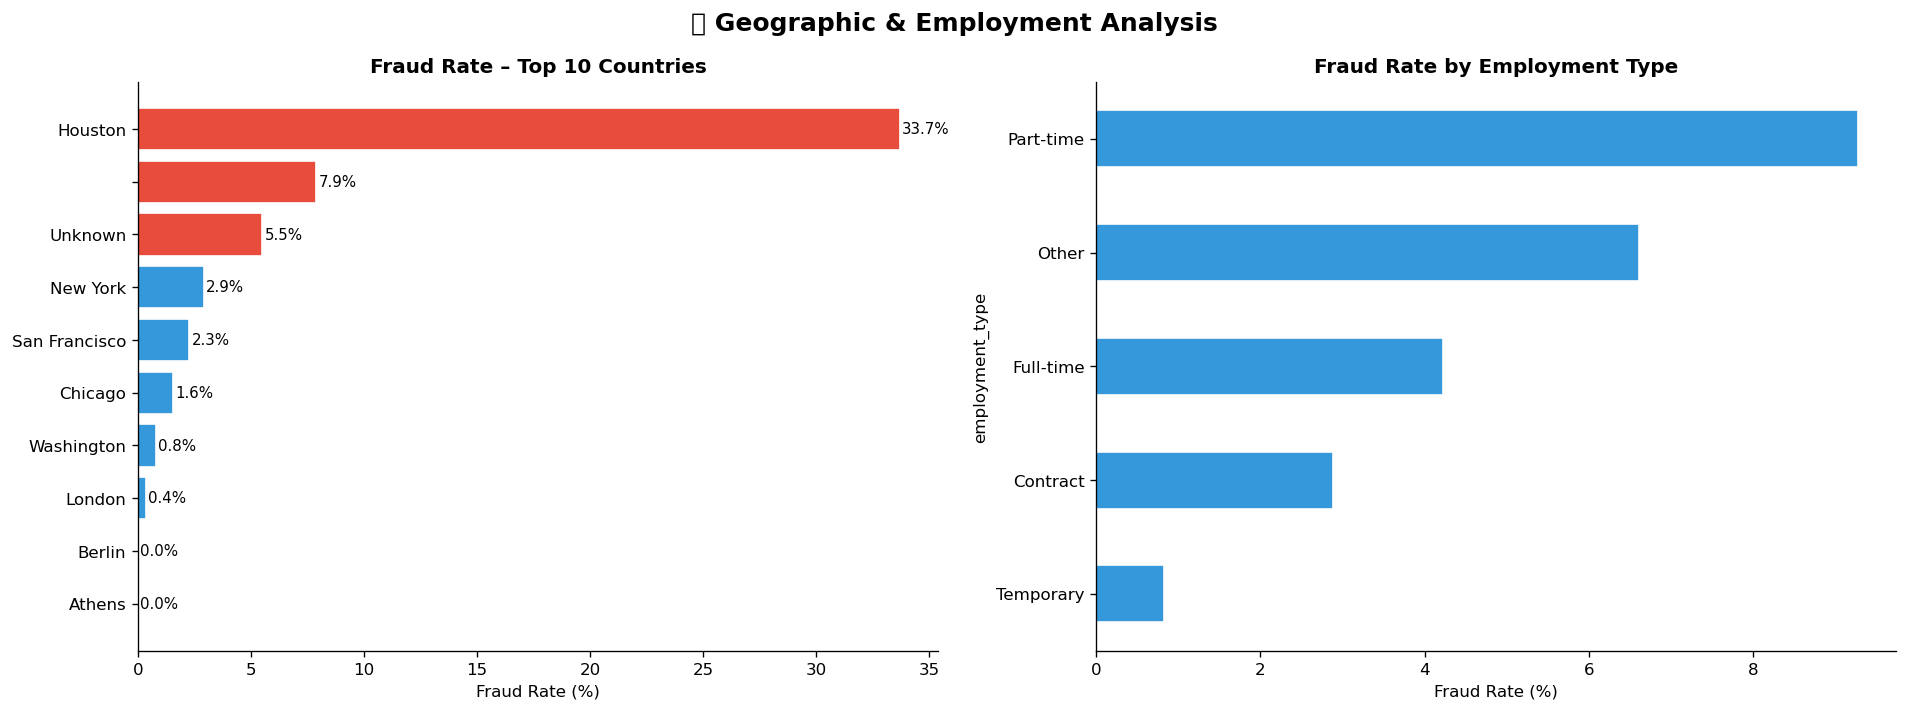

💾 Saved: 03_geo_employment.png


In [9]:
# ── Chart 3: Top Countries & Employment Type ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🌍 Geographic & Employment Analysis', fontsize=15, fontweight='bold')

# Country fraud rate
top_countries = df.groupby('country').agg(
    total=('fraudulent', 'count'),
    fraud=('fraudulent', 'sum')
).query('total >= 50')
top_countries['fraud_rate'] = (top_countries['fraud'] / top_countries['total'] * 100).round(2)
top_countries = top_countries.nlargest(10, 'total')
top_countries = top_countries.sort_values('fraud_rate')

colors_c = [COLORS['fake'] if r > 5 else COLORS['neutral'] for r in top_countries['fraud_rate']]
axes[0].barh(top_countries.index, top_countries['fraud_rate'], color=colors_c, edgecolor='white')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate – Top 10 Countries', fontweight='bold')
for i, (val, idx) in enumerate(zip(top_countries['fraud_rate'], top_countries.index)):
    axes[0].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# Employment type
if 'employment_type' in df.columns:
    et = df.groupby('employment_type')['fraudulent'].agg(['sum', 'count'])
    et.columns = ['Fraud', 'Total']
    et['Fraud_Rate'] = (et['Fraud'] / et['Total'] * 100).round(2)
    et = et.dropna().sort_values('Fraud_Rate', ascending=True)
    et['Fraud_Rate'].plot(kind='barh', ax=axes[1], color=COLORS['neutral'], edgecolor='white')
    axes[1].set_xlabel('Fraud Rate (%)')
    axes[1].set_title('Fraud Rate by Employment Type', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_geo_employment.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 03_geo_employment.png")

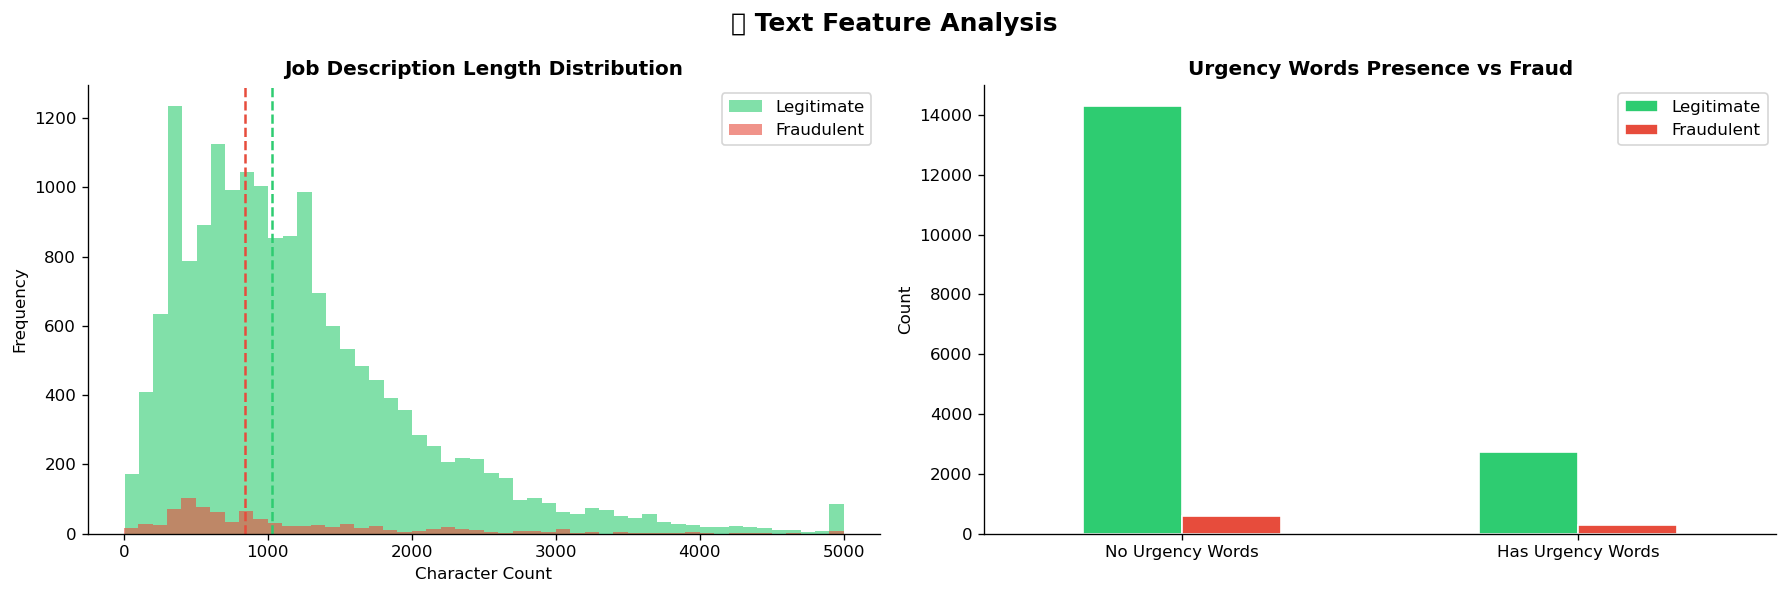

💾 Saved: 04_text_features.png


In [10]:
# ── Chart 4: Description Length & Urgency Words ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('📝 Text Feature Analysis', fontsize=15, fontweight='bold')

# Description length
for fraud_val, label, color in [(0, 'Legitimate', COLORS['real']), (1, 'Fraudulent', COLORS['fake'])]:
    data = df[df['fraudulent'] == fraud_val]['desc_length']
    data.clip(0, 5000).plot.hist(ax=axes[0], bins=50, alpha=0.6, label=label, color=color)
axes[0].set_title('Job Description Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].axvline(df[df['fraudulent']==1]['desc_length'].median(), color=COLORS['fake'],
               linestyle='--', label='Fake Median')
axes[0].axvline(df[df['fraudulent']==0]['desc_length'].median(), color=COLORS['real'],
               linestyle='--', label='Real Median')

# Urgency words
uw = df.groupby(['has_urgency_words', 'fraudulent']).size().unstack(fill_value=0)
uw.index = ['No Urgency Words', 'Has Urgency Words']
uw.columns = ['Legitimate', 'Fraudulent']
uw.plot(kind='bar', ax=axes[1], color=[COLORS['real'], COLORS['fake']], edgecolor='white', width=0.5)
axes[1].set_title('Urgency Words Presence vs Fraud', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_text_features.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 04_text_features.png")

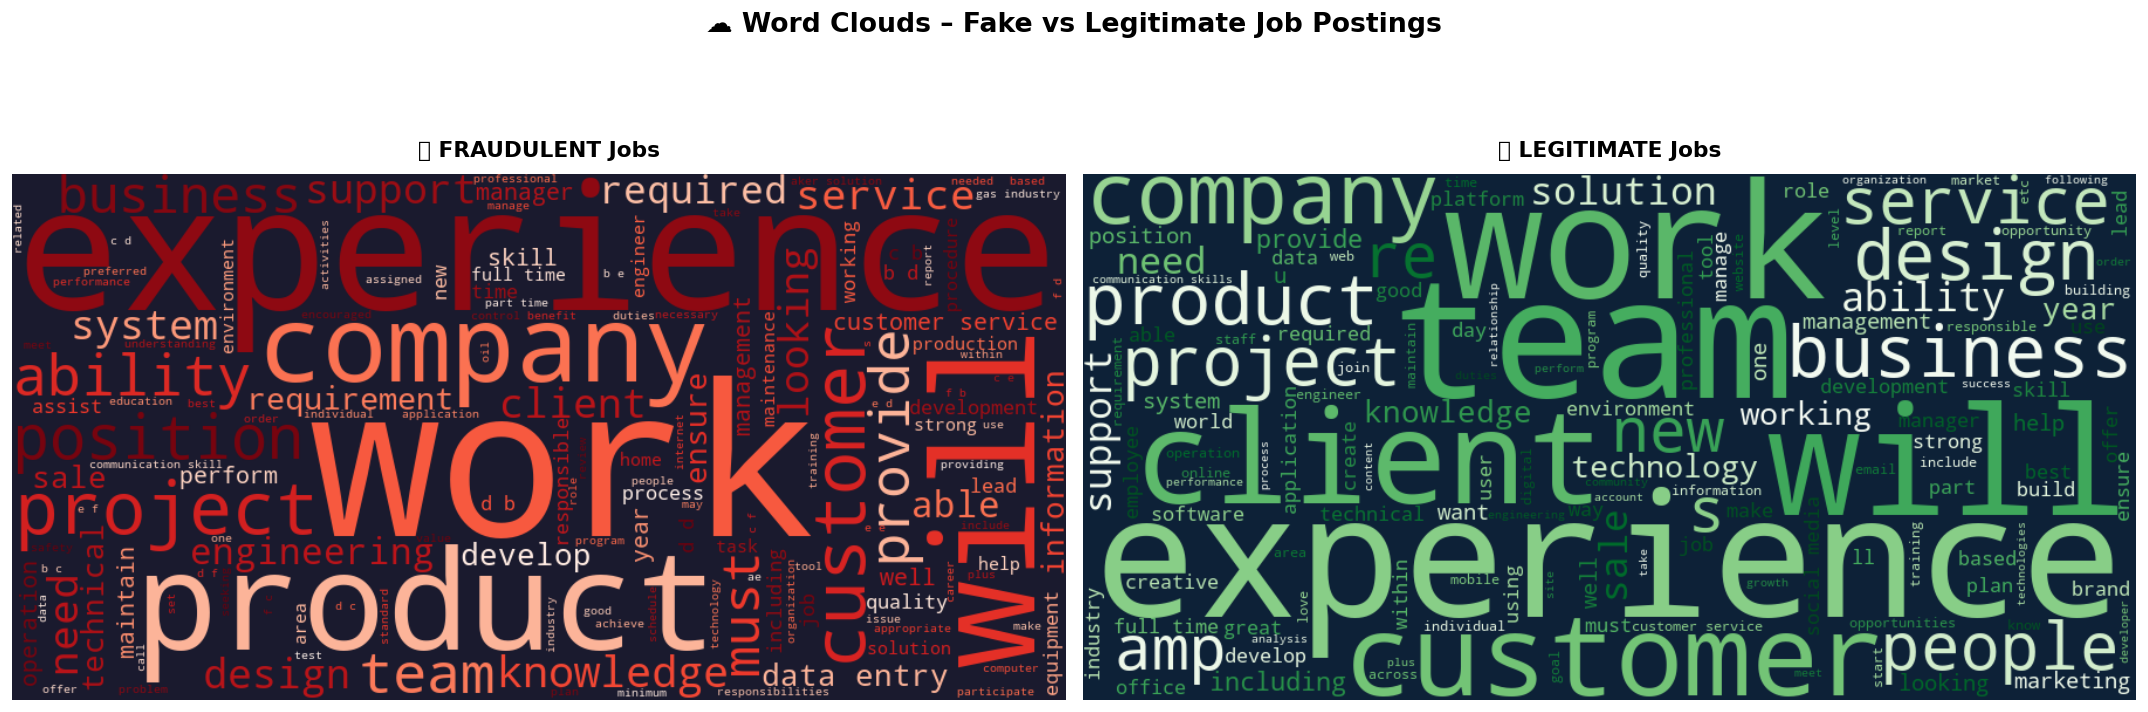

💾 Saved: 05_wordclouds.png


In [11]:
# ── Chart 5: Word Clouds ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('☁️ Word Clouds – Fake vs Legitimate Job Postings', fontsize=16, fontweight='bold')

for ax, fraud_val, title, bg, cmap in [
    (axes[0], 1, '🚨 FRAUDULENT Jobs', '#1a1a2e', 'Reds'),
    (axes[1], 0, '✅ LEGITIMATE Jobs', '#0d2137', 'Greens')
]:
    texts = ' '.join(df[df['fraudulent'] == fraud_val]['combined_text'].sample(min(500, len(df)), random_state=42))
    wc = WordCloud(
        width=900, height=450, background_color=bg,
        colormap=cmap, max_words=150, contour_width=2,
        min_font_size=8, prefer_horizontal=0.7
    ).generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_wordclouds.png', bbox_inches='tight', facecolor='#0a0a1a')
plt.show()
print("💾 Saved: 05_wordclouds.png")

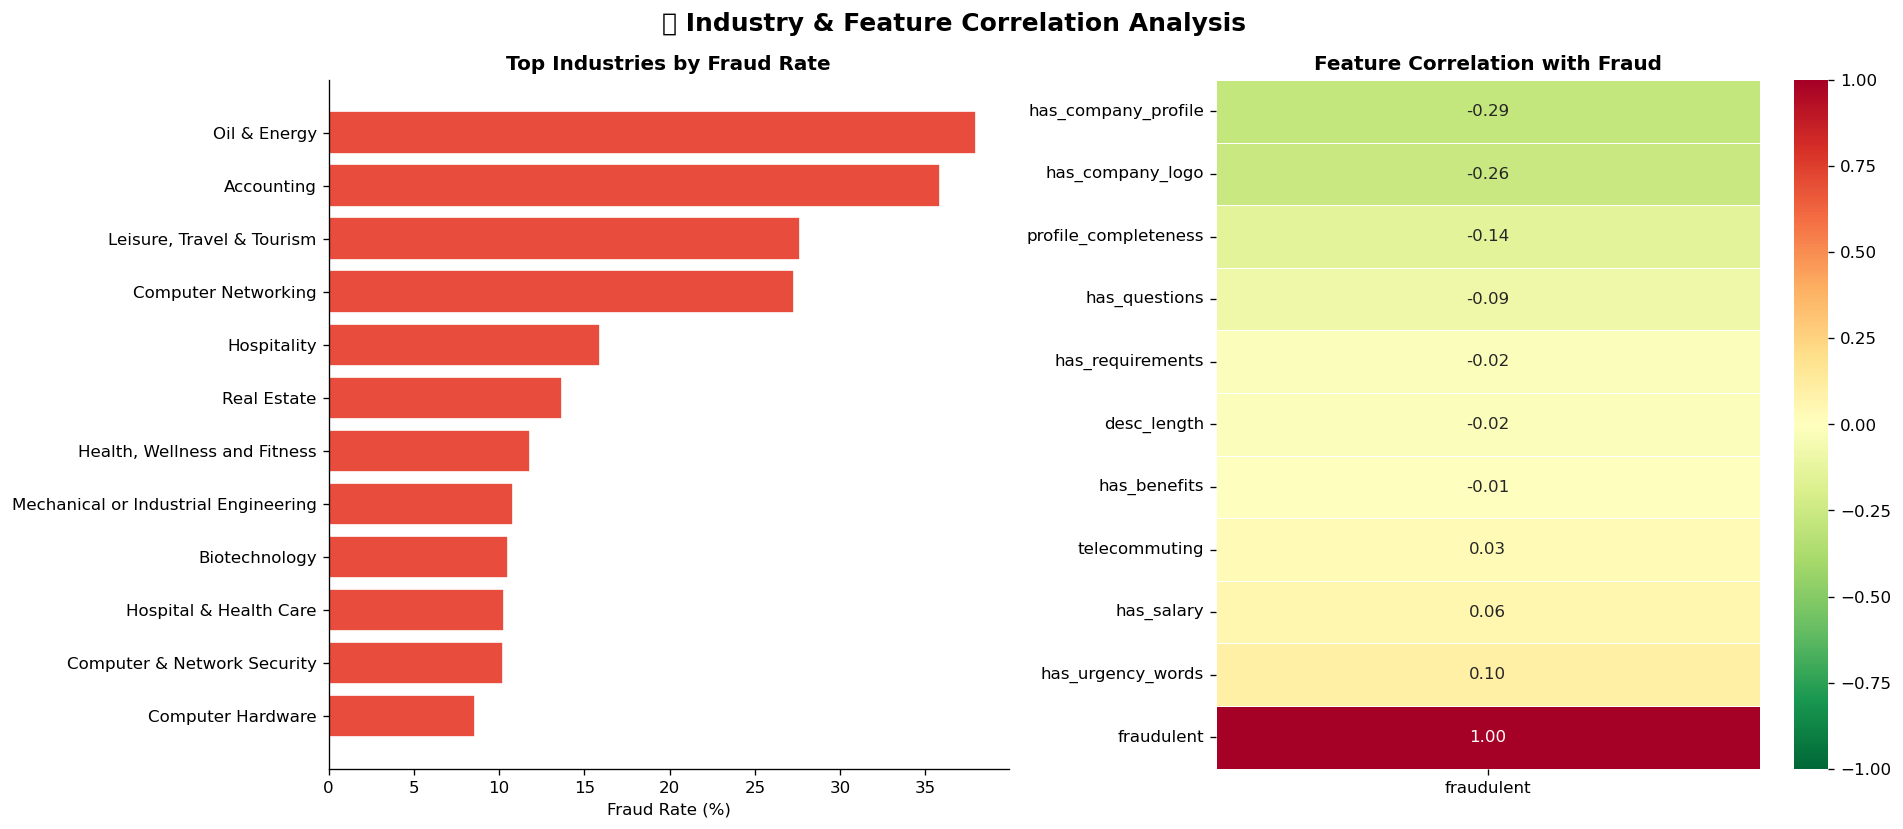

💾 Saved: 06_industry_correlation.png


In [12]:
# ── Chart 6: Industry & Numeric Feature Correlation ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🏭 Industry & Feature Correlation Analysis', fontsize=15, fontweight='bold')

# Industry fraud rate
if 'industry' in df.columns:
    ind = df.dropna(subset=['industry']).groupby('industry')['fraudulent'].agg(['sum', 'count'])
    ind.columns = ['Fraud', 'Total']
    ind['Rate'] = ind['Fraud'] / ind['Total'] * 100
    top_ind = ind[ind['Total'] >= 30].nlargest(12, 'Rate').sort_values('Rate')
    colors_i = [COLORS['fake'] if r > 8 else COLORS['neutral'] for r in top_ind['Rate']]
    axes[0].barh(top_ind.index, top_ind['Rate'], color=colors_i, edgecolor='white')
    axes[0].set_xlabel('Fraud Rate (%)')
    axes[0].set_title('Top Industries by Fraud Rate', fontweight='bold')

# Correlation heatmap
num_cols = ['has_salary', 'has_company_profile', 'has_requirements', 'has_benefits',
            'has_company_logo', 'has_questions', 'telecommuting', 'has_urgency_words',
            'desc_length', 'profile_completeness', 'fraudulent']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr[['fraudulent']].sort_values('fraudulent'), annot=True, fmt='.2f',
            cmap='RdYlGn_r', ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Feature Correlation with Fraud', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_industry_correlation.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 06_industry_correlation.png")

In [13]:
# ── EDA Summary Statistics ────────────────────────────────────────────────
print("=" * 55)
print("📊  EDA KEY FINDINGS SUMMARY")
print("=" * 55)

real = df[df['fraudulent'] == 0]
fake = df[df['fraudulent'] == 1]

print(f"\n📌 Total Postings  : {len(df):,}")
print(f"   ✅ Legitimate    : {len(real):,} ({len(real)/len(df)*100:.2f}%)")
print(f"   🚨 Fraudulent    : {len(fake):,} ({len(fake)/len(df)*100:.2f}%)")

print(f"\n📌 Missing Salary  :")
print(f"   Legitimate       : {real['has_salary'].mean()*100:.1f}% have salary")
print(f"   Fraudulent       : {fake['has_salary'].mean()*100:.1f}% have salary  ← Key signal!")

print(f"\n📌 Urgency Words   :")
print(f"   Legitimate       : {real['has_urgency_words'].mean()*100:.1f}% contain urgency words")
print(f"   Fraudulent       : {fake['has_urgency_words'].mean()*100:.1f}% contain urgency words  ← Key signal!")

print(f"\n📌 Avg Description Length:")
print(f"   Legitimate       : {real['desc_length'].mean():.0f} chars")
print(f"   Fraudulent       : {fake['desc_length'].mean():.0f} chars  ← Shorter on average")

print(f"\n📌 Profile Completeness Avg:")
print(f"   Legitimate       : {real['profile_completeness'].mean():.2f} / 6")
print(f"   Fraudulent       : {fake['profile_completeness'].mean():.2f} / 6  ← Less complete!")

print("\n✅ EDA Phase Complete!")

📊  EDA KEY FINDINGS SUMMARY

📌 Total Postings  : 17,880
   ✅ Legitimate    : 17,014 (95.16%)
   🚨 Fraudulent    : 866 (4.84%)

📌 Missing Salary  :
   Legitimate       : 15.5% have salary
   Fraudulent       : 25.8% have salary  ← Key signal!

📌 Urgency Words   :
   Legitimate       : 16.0% contain urgency words
   Fraudulent       : 33.4% contain urgency words  ← Key signal!

📌 Avg Description Length:
   Legitimate       : 1221 chars
   Fraudulent       : 1155 chars  ← Shorter on average

📌 Profile Completeness Avg:
   Legitimate       : 3.62 / 6
   Fraudulent       : 2.70 / 6  ← Less complete!

✅ EDA Phase Complete!


## 5️⃣ SQL Analysis (SQLite) <a id='5'></a>

In [14]:
# ── Load Cleaned Data into SQLite ────────────────────────────────────────
conn = sqlite3.connect(':memory:')  # In-memory DB for notebook demo

# Prepare a clean dataframe for SQL
sql_df = df[[
    'job_id', 'title', 'location', 'country', 'department', 'salary_range',
    'employment_type', 'required_experience', 'required_education',
    'industry', 'function', 'telecommuting', 'has_company_logo', 'has_questions',
    'has_salary', 'has_company_profile', 'has_requirements', 'has_benefits',
    'has_urgency_words', 'desc_length', 'profile_completeness', 'fraudulent'
]].copy()
sql_df['salary_status'] = sql_df['has_salary'].map({1: 'Disclosed', 0: 'Not Disclosed'})
sql_df.to_sql('job_postings', conn, if_exists='replace', index=False)

print(f"✅ Loaded {len(sql_df):,} records into SQLite table 'job_postings'")
print("\nTable Schema:")
schema = pd.read_sql("PRAGMA table_info(job_postings)", conn)
print(schema[['name', 'type']].to_string(index=False))

✅ Loaded 17,880 records into SQLite table 'job_postings'

Table Schema:
                name    type
              job_id INTEGER
               title    TEXT
            location    TEXT
             country    TEXT
          department    TEXT
        salary_range    TEXT
     employment_type    TEXT
 required_experience    TEXT
  required_education    TEXT
            industry    TEXT
            function    TEXT
       telecommuting INTEGER
    has_company_logo INTEGER
       has_questions INTEGER
          has_salary INTEGER
 has_company_profile INTEGER
    has_requirements INTEGER
        has_benefits INTEGER
   has_urgency_words INTEGER
         desc_length INTEGER
profile_completeness INTEGER
          fraudulent INTEGER
       salary_status    TEXT


In [15]:
# ── Q1: Overall Fraud Summary ────────────────────────────────────────────
q1 = pd.read_sql("""
    SELECT
        SUM(CASE WHEN fraudulent = 1 THEN 1 ELSE 0 END)        AS total_fake,
        SUM(CASE WHEN fraudulent = 0 THEN 1 ELSE 0 END)        AS total_real,
        COUNT(*)                                                 AS total_jobs,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)           AS fraud_rate_pct,
        ROUND(AVG(CASE WHEN fraudulent=1 THEN desc_length END)) AS avg_fake_desc_len,
        ROUND(AVG(CASE WHEN fraudulent=0 THEN desc_length END)) AS avg_real_desc_len
    FROM job_postings
""", conn)
print("📊 Q1 – OVERALL FRAUD SUMMARY")
print(q1.to_string(index=False))

📊 Q1 – OVERALL FRAUD SUMMARY
 total_fake  total_real  total_jobs  fraud_rate_pct  avg_fake_desc_len  avg_real_desc_len
        866       17014       17880            4.84             1155.0             1221.0


In [16]:
# ── Q2: Fraud by Country (Top 10) ────────────────────────────────────────
q2 = pd.read_sql("""
    SELECT
        country,
        COUNT(*)                                          AS total_postings,
        SUM(fraudulent)                                   AS fraud_count,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct
    FROM job_postings
    WHERE country != 'Unknown'
    GROUP BY country
    HAVING total_postings >= 50
    ORDER BY fraud_rate_pct DESC
    LIMIT 10
""", conn)
print("\n📊 Q2 – FRAUD BY COUNTRY (Top 10 by Fraud Rate)")
print(q2.to_string(index=False))


📊 Q2 – FRAUD BY COUNTRY (Top 10 by Fraud Rate)
     country  total_postings  fraud_count  fraud_rate_pct
      Sydney              84           31           36.90
     Houston             273           92           33.70
    San Jose              51           16           31.37
 Los Angeles             192           23           11.98
     Seattle              59            6           10.17
  Cincinnati              92            8            8.70
                        1635          129            7.89
          US              64            5            7.81
      Denver              50            3            6.00
Jacksonville              54            3            5.56


In [17]:
# ── Q3: Salary Disclosure vs Fraud ───────────────────────────────────────
q3 = pd.read_sql("""
    SELECT
        salary_status,
        COUNT(*)                                          AS total_jobs,
        SUM(fraudulent)                                   AS fraud_count,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct
    FROM job_postings
    GROUP BY salary_status
    ORDER BY fraud_rate_pct DESC
""", conn)
print("\n📊 Q3 – SALARY DISCLOSURE vs FRAUD")
print(q3.to_string(index=False))


📊 Q3 – SALARY DISCLOSURE vs FRAUD
salary_status  total_jobs  fraud_count  fraud_rate_pct
    Disclosed        2868          223            7.78
Not Disclosed       15012          643            4.28


In [18]:
# ── Q4: Employment Type Fraud Analysis ───────────────────────────────────
q4 = pd.read_sql("""
    SELECT
        COALESCE(employment_type, 'Not Specified')        AS employment_type,
        COUNT(*)                                          AS total_jobs,
        SUM(fraudulent)                                   AS fraud_count,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct
    FROM job_postings
    GROUP BY employment_type
    HAVING total_jobs >= 20
    ORDER BY fraud_rate_pct DESC
""", conn)
print("\n📊 Q4 – EMPLOYMENT TYPE FRAUD ANALYSIS")
print(q4.to_string(index=False))


📊 Q4 – EMPLOYMENT TYPE FRAUD ANALYSIS
employment_type  total_jobs  fraud_count  fraud_rate_pct
      Part-time         797           74            9.28
  Not Specified        3471          241            6.94
          Other         227           15            6.61
      Full-time       11620          490            4.22
       Contract        1524           44            2.89
      Temporary         241            2            0.83


In [19]:
# ── Q5: Profile Completeness Risk Analysis ───────────────────────────────
q5 = pd.read_sql("""
    SELECT
        profile_completeness,
        COUNT(*)                                          AS total_jobs,
        SUM(fraudulent)                                   AS fraud_count,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct,
        CASE
            WHEN profile_completeness <= 1 THEN 'HIGH RISK'
            WHEN profile_completeness <= 3 THEN 'MEDIUM RISK'
            ELSE 'LOW RISK'
        END                                               AS risk_level
    FROM job_postings
    GROUP BY profile_completeness
    ORDER BY profile_completeness
""", conn)
print("\n📊 Q5 – PROFILE COMPLETENESS RISK ANALYSIS")
print(q5.to_string(index=False))


📊 Q5 – PROFILE COMPLETENESS RISK ANALYSIS
 profile_completeness  total_jobs  fraud_count  fraud_rate_pct  risk_level
                    0         425          114           26.82   HIGH RISK
                    1        1184          122           10.30   HIGH RISK
                    2        2086          190            9.11 MEDIUM RISK
                    3        3669          149            4.06 MEDIUM RISK
                    4        5997          141            2.35    LOW RISK
                    5        3620           79            2.18    LOW RISK
                    6         899           71            7.90    LOW RISK


In [20]:
# ── Q6: Industry Fraud Leaderboard ───────────────────────────────────────
q6 = pd.read_sql("""
    SELECT
        COALESCE(industry, 'Unknown')                     AS industry,
        COUNT(*)                                          AS total_jobs,
        SUM(fraudulent)                                   AS fraud_count,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct
    FROM job_postings
    WHERE industry IS NOT NULL
    GROUP BY industry
    HAVING total_jobs >= 30
    ORDER BY fraud_rate_pct DESC
    LIMIT 10
""", conn)
print("\n📊 Q6 – TOP INDUSTRIES BY FRAUD RATE")
print(q6.to_string(index=False))


📊 Q6 – TOP INDUSTRIES BY FRAUD RATE
                            industry  total_jobs  fraud_count  fraud_rate_pct
                        Oil & Energy         287          109           37.98
                          Accounting         159           57           35.85
           Leisure, Travel & Tourism          76           21           27.63
                 Computer Networking          44           12           27.27
                         Hospitality          88           14           15.91
                         Real Estate         175           24           13.71
        Health, Wellness and Fitness         127           15           11.81
Mechanical or Industrial Engineering          37            4           10.81
                       Biotechnology          38            4           10.53
              Hospital & Health Care         497           51           10.26


In [21]:
# ── Q7: Combined Risk Scoring ────────────────────────────────────────────
q7 = pd.read_sql("""
    SELECT
        CASE
            WHEN has_salary = 0 AND has_company_logo = 0 AND has_urgency_words = 1 THEN 'VERY HIGH RISK'
            WHEN has_salary = 0 AND has_company_logo = 0                           THEN 'HIGH RISK'
            WHEN has_salary = 0 OR  has_urgency_words = 1                          THEN 'MEDIUM RISK'
            ELSE                                                                        'LOW RISK'
        END                                               AS risk_category,
        COUNT(*)                                          AS total_jobs,
        SUM(fraudulent)                                   AS actual_fraud,
        ROUND(100.0 * SUM(fraudulent) / COUNT(*), 2)     AS fraud_rate_pct
    FROM job_postings
    GROUP BY risk_category
    ORDER BY fraud_rate_pct DESC
""", conn)
print("\n📊 Q7 – COMBINED RISK SCORING MATRIX")
print(q7.to_string(index=False))
conn.close()


📊 Q7 – COMBINED RISK SCORING MATRIX
 risk_category  total_jobs  actual_fraud  fraud_rate_pct
VERY HIGH RISK         607           228           37.56
     HIGH RISK        2312           227            9.82
      LOW RISK        2352           177            7.53
   MEDIUM RISK       12609           234            1.86


## 6️⃣ Machine Learning – Model Training <a id='6'></a>

In [22]:
# ── Prepare Data ─────────────────────────────────────────────────────────
# Drop rows without text
df_ml = df.dropna(subset=['combined_text']).copy()
df_ml = df_ml[df_ml['combined_text'].str.len() > 10].copy()

# Target
y = df_ml['fraudulent'].values

# TF-IDF Vectorisation
print("🔄 Building TF-IDF matrix...")
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_text = tfidf.fit_transform(df_ml['combined_text'])
print(f"✅ TF-IDF Matrix: {X_text.shape[0]:,} samples × {X_text.shape[1]:,} features")

# Numeric features
num_cols = ['has_salary', 'has_company_profile', 'has_requirements',
            'has_benefits', 'has_company_logo', 'has_questions',
            'telecommuting', 'has_urgency_words', 'profile_completeness',
            'desc_length', 'req_length']
X_num = csr_matrix(df_ml[num_cols].fillna(0).values)

# Combine
X = hstack([X_text, X_num])
print(f"✅ Final Feature Matrix: {X.shape[0]:,} samples × {X.shape[1]:,} features")
print(f"📊 Class Balance: {(y==0).sum():,} legitimate | {(y==1).sum():,} fraudulent")

🔄 Building TF-IDF matrix...
✅ TF-IDF Matrix: 17,880 samples × 10,000 features
✅ Final Feature Matrix: 17,880 samples × 10,011 features
📊 Class Balance: 17,014 legitimate | 866 fraudulent


In [23]:
# ── Train-Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"🔀 Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"   Train fraud: {y_train.sum():,} | Test fraud: {y_test.sum():,}")
print(f"   Train fraud rate: {y_train.mean()*100:.2f}%")

# ── SMOTE: Apply on training set ONLY ────────────────────────────────────
# ⚠️  Test set keeps ORIGINAL distribution to simulate real-world performance
if SMOTE_AVAILABLE:
    print("\n🔄 Applying SMOTE oversampling on TRAINING set only...")
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print(f"✅ After SMOTE → Train: {X_train_sm.shape[0]:,}")
    print(f"   Legitimate: {(y_train_sm==0).sum():,} | Fraudulent: {(y_train_sm==1).sum():,}")
    print(f"   Balanced ratio: {y_train_sm.mean()*100:.1f}% fraud (was {y_train.mean()*100:.2f}%)")
else:
    print("⚠️  SMOTE not available – using class_weight='balanced' instead")
    X_train_sm, y_train_sm = X_train, y_train

# ── Model Definitions ─────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, C=1.0
        # Note: class_weight NOT needed since SMOTE already balanced the data
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

results = {}
print("\n🚀 Training models (on SMOTE-balanced training set)...")


🔀 Train: 14,304 | Test: 3,576
   Train fraud: 693 | Test fraud: 173
   Train fraud rate: 4.84%

🔄 Applying SMOTE oversampling on TRAINING set only...
✅ After SMOTE → Train: 27,222
   Legitimate: 13,611 | Fraudulent: 13,611
   Balanced ratio: 50.0% fraud (was 4.84%)

🚀 Training models (on SMOTE-balanced training set)...


In [24]:
# ── Train & Evaluate All Models (using SMOTE-balanced training data) ────────
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    # FIXED: Train on SMOTE-balanced data, evaluate on ORIGINAL test set
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    acc   = accuracy_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'precision': prec,
        'recall'   : rec,
        'f1'       : f1,
        'accuracy' : acc,
        'auc'      : auc
    }

    print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%)")
    print(f"  Recall    : {rec:.4f}  ({rec*100:.1f}%)")
    print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%)")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    if auc: print(f"  AUC-ROC   : {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

print("\n✅ All models trained successfully!")



  Training: Logistic Regression
  Precision : 0.4681  (46.8%)
  Recall    : 0.8902  (89.0%)
  F1 Score  : 0.6135  (61.4%)
  Accuracy  : 0.9457  (94.6%)
  AUC-ROC   : 0.9834

              precision    recall  f1-score   support

  Legitimate       0.99      0.95      0.97      3403
  Fraudulent       0.47      0.89      0.61       173

    accuracy                           0.95      3576
   macro avg       0.73      0.92      0.79      3576
weighted avg       0.97      0.95      0.95      3576


  Training: Naive Bayes
  Precision : 0.0763  (7.6%)
  Recall    : 0.6705  (67.1%)
  F1 Score  : 0.1370  (13.7%)
  Accuracy  : 0.5914  (59.1%)
  AUC-ROC   : 0.6435

              precision    recall  f1-score   support

  Legitimate       0.97      0.59      0.73      3403
  Fraudulent       0.08      0.67      0.14       173

    accuracy                           0.59      3576
   macro avg       0.52      0.63      0.43      3576
weighted avg       0.93      0.59      0.70      3576


  Tr

🔄 Running 5-Fold Stratified Cross-Validation on Logistic Regression...

✅ 5-Fold CV AUC Scores: [0.985  0.9828 0.9802 0.981  0.9694]
   Mean AUC : 0.9797
   Std  AUC : 0.0054

🎯 Threshold Tuning Analysis...


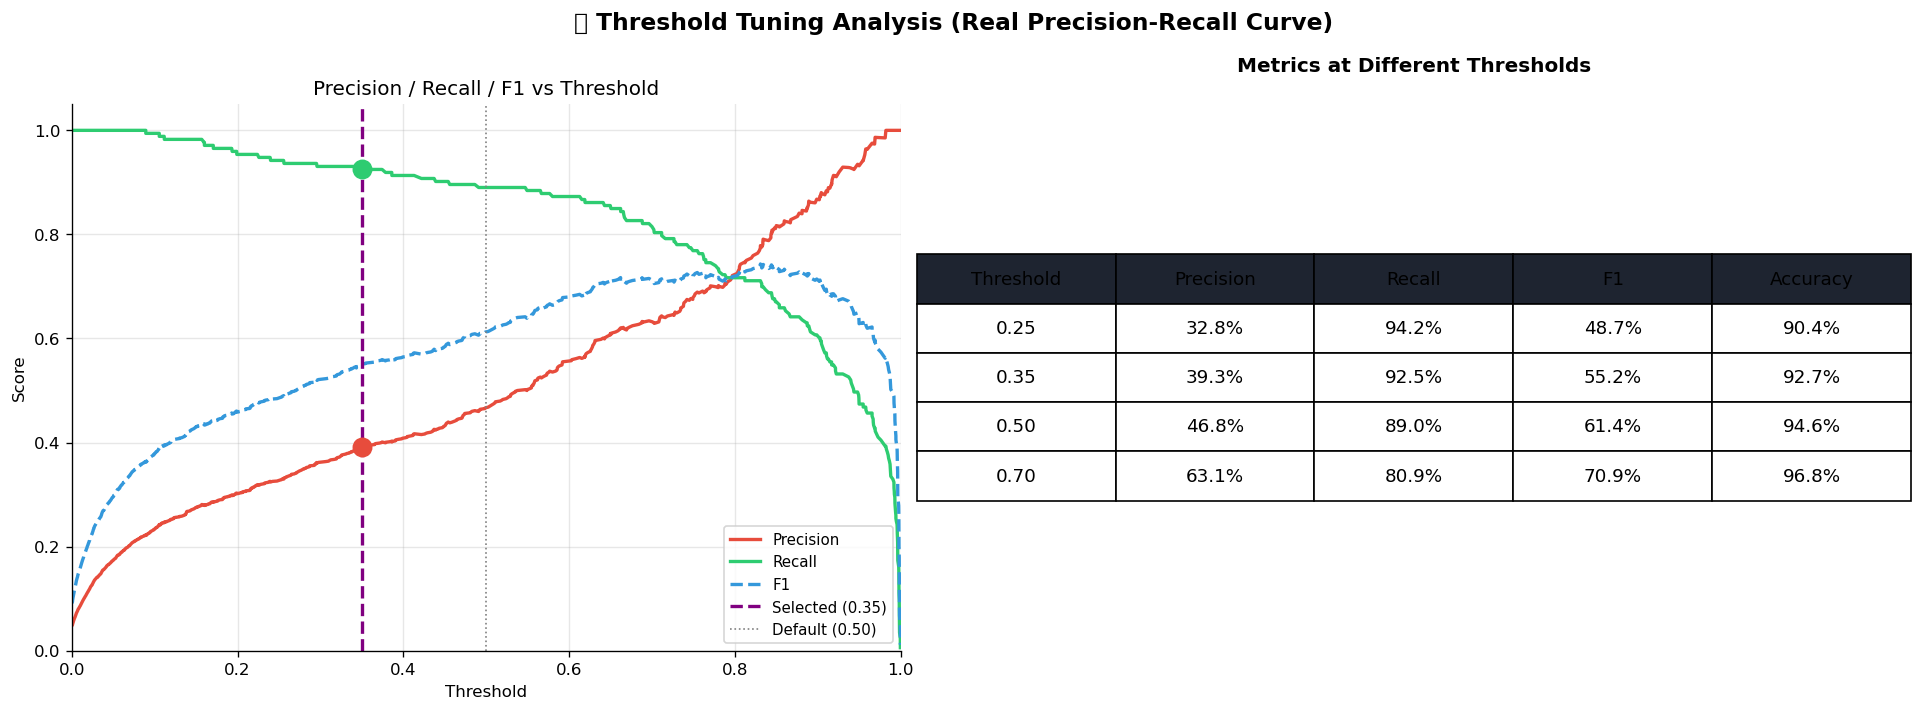

💾 Saved: 12_threshold_tuning.png

📊 Logistic Regression @ threshold=0.35:
   Precision : 39.3%
   Recall    : 92.5%
   F1-Score  : 55.2%
   5-Fold CV AUC: 0.9797 ± 0.0054


In [25]:
# ── 5-Fold Stratified Cross-Validation ──────────────────────────────────────
print("🔄 Running 5-Fold Stratified Cross-Validation on Logistic Regression...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_model = results['Logistic Regression']['model']

cv_auc_scores = cross_val_score(lr_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"\n✅ 5-Fold CV AUC Scores: {cv_auc_scores.round(4)}")
print(f"   Mean AUC : {cv_auc_scores.mean():.4f}")
print(f"   Std  AUC : {cv_auc_scores.std():.4f}")

# ── Threshold Tuning (FIXED – Real precision-recall curve) ───────────────────
print("\n🎯 Threshold Tuning Analysis...")
lr_proba = results['Logistic Regression']['y_proba']
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_proba)
f1_scores_thr = 2 * precisions * recalls / (precisions + recalls + 1e-9)

# Find best F1 threshold
best_thr_idx = np.argmax(f1_scores_thr)
best_thr     = thresholds[best_thr_idx] if best_thr_idx < len(thresholds) else 0.5

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🎯 Threshold Tuning Analysis (Real Precision-Recall Curve)', fontsize=14, fontweight='bold')

# Precision-Recall vs Threshold
ax = axes[0]
ax.plot(thresholds, precisions[:-1], color=COLORS['fake'], lw=2, label='Precision')
ax.plot(thresholds, recalls[:-1],    color=COLORS['real'], lw=2, label='Recall')
ax.plot(thresholds, f1_scores_thr[:-1], color=COLORS['neutral'], lw=2, ls='--', label='F1')
ax.axvline(x=0.35, color='purple', lw=2, ls='--', label='Selected (0.35)')
ax.axvline(x=0.50, color='gray',   lw=1, ls=':',  label='Default (0.50)')
ax.scatter([0.35], [precisions[np.argmin(np.abs(thresholds-0.35))]],
           color=COLORS['fake'], s=120, zorder=5)
ax.scatter([0.35], [recalls[np.argmin(np.abs(thresholds-0.35))]],
           color=COLORS['real'], s=120, zorder=5)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

# Impact comparison table
ax2 = axes[1]
ax2.axis('off')

def metrics_at_threshold(threshold):
    y_pred_thr = (lr_proba >= threshold).astype(int)
    return {
        'Precision': precision_score(y_test, y_pred_thr, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred_thr),
        'F1'       : f1_score(y_test, y_pred_thr),
        'Accuracy' : accuracy_score(y_test, y_pred_thr),
    }

thr_comparison = []
for thr in [0.25, 0.35, 0.50, 0.70]:
    m = metrics_at_threshold(thr)
    thr_comparison.append([
        f"{thr:.2f}", f"{m['Precision']*100:.1f}%",
        f"{m['Recall']*100:.1f}%", f"{m['F1']*100:.1f}%",
        f"{m['Accuracy']*100:.1f}%"
    ])

table = ax2.table(
    cellText   = thr_comparison,
    colLabels  = ['Threshold', 'Precision', 'Recall', 'F1', 'Accuracy'],
    cellLoc    = 'center', loc='center',
    colColours = ['#1e2430']*5,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)
ax2.set_title('Metrics at Different Thresholds', fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_threshold_tuning.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 12_threshold_tuning.png")

# Apply threshold = 0.35 to best model
FRAUD_THRESHOLD = 0.35
lr_pred_tuned = (lr_proba >= FRAUD_THRESHOLD).astype(int)
print(f"\n📊 Logistic Regression @ threshold={FRAUD_THRESHOLD}:")
print(f"   Precision : {precision_score(y_test, lr_pred_tuned)*100:.1f}%")
print(f"   Recall    : {recall_score(y_test, lr_pred_tuned)*100:.1f}%")
print(f"   F1-Score  : {f1_score(y_test, lr_pred_tuned)*100:.1f}%")
print(f"   5-Fold CV AUC: {cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}")

# Update results dict with tuned prediction
results['Logistic Regression']['y_pred_tuned']  = lr_pred_tuned
results['Logistic Regression']['threshold']     = FRAUD_THRESHOLD
results['Logistic Regression']['recall_tuned']  = recall_score(y_test, lr_pred_tuned)
results['Logistic Regression']['f1_tuned']      = f1_score(y_test, lr_pred_tuned)
results['Logistic Regression']['cv_auc_mean']   = cv_auc_scores.mean()
results['Logistic Regression']['cv_auc_std']    = cv_auc_scores.std()


## 7️⃣ Model Evaluation & Comparison <a id='7'></a>

In [26]:
# ── Comparison Table ──────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'Model'    : name,
    'Precision': f"{r['precision']*100:.1f}%",
    'Recall'   : f"{r['recall']*100:.1f}%",
    'F1-Score' : f"{r['f1']*100:.1f}%",
    'Accuracy' : f"{r['accuracy']*100:.1f}%",
    'AUC-ROC'  : f"{r['auc']:.4f}" if r['auc'] else 'N/A'
} for name, r in results.items()])

print("=" * 75)
print("📊 MODEL COMPARISON TABLE")
print("=" * 75)
print(metrics_df.to_string(index=False))
print("=" * 75)

# Best model
best_name = max(results, key=lambda n: results[n]['f1'])
best = results[best_name]
print(f"\n🏆 BEST MODEL (by F1): {best_name}")
print(f"   Precision: {best['precision']*100:.1f}%")
print(f"   Recall   : {best['recall']*100:.1f}%")
print(f"   F1-Score : {best['f1']*100:.1f}%")
print(f"   AUC-ROC  : {best['auc']:.4f}")

📊 MODEL COMPARISON TABLE
              Model Precision Recall F1-Score Accuracy AUC-ROC
Logistic Regression     46.8%  89.0%    61.4%    94.6%  0.9834
        Naive Bayes      7.6%  67.1%    13.7%    59.1%  0.6435
      Random Forest    100.0%  68.8%    81.5%    98.5%  0.9929

🏆 BEST MODEL (by F1): Random Forest
   Precision: 100.0%
   Recall   : 68.8%
   F1-Score : 81.5%
   AUC-ROC  : 0.9929


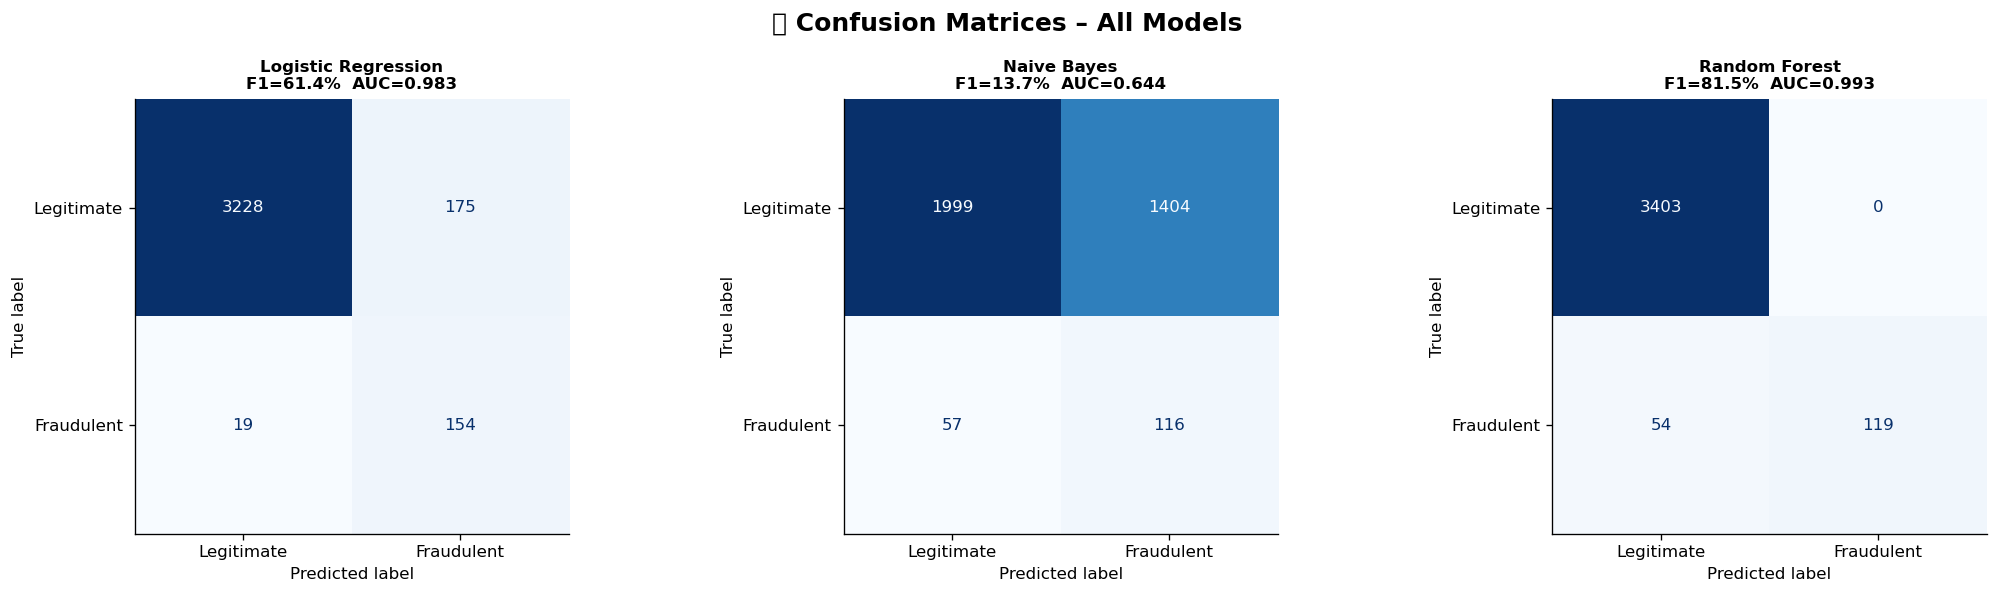

💾 Saved: 07_confusion_matrices.png


In [27]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Confusion Matrices – All Models', fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraudulent'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={r["f1"]*100:.1f}%  AUC={r["auc"]:.3f}',
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 07_confusion_matrices.png")

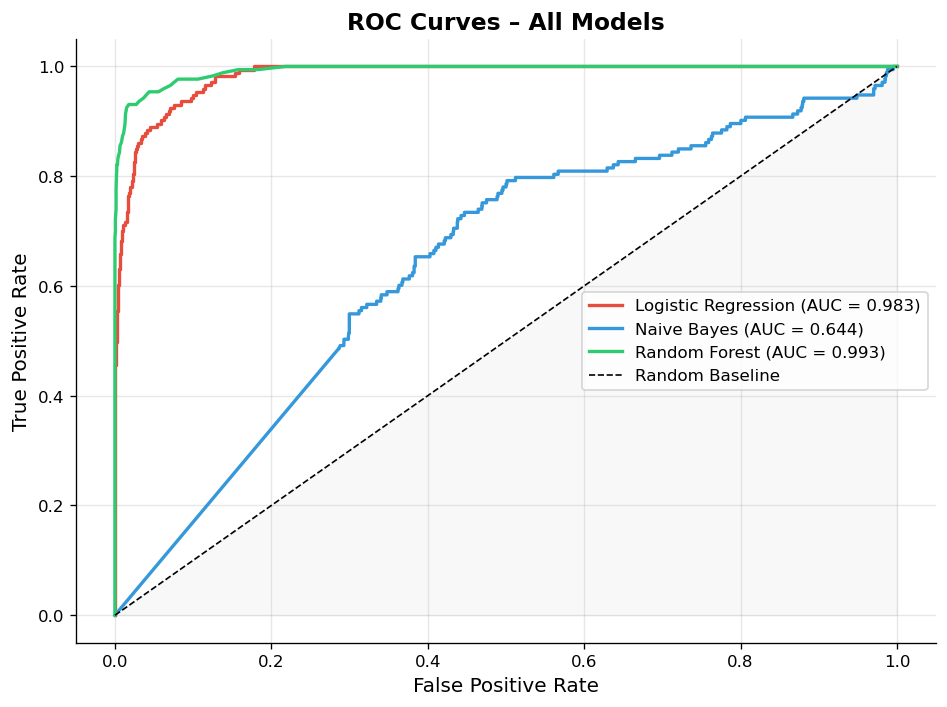

💾 Saved: 08_roc_curves.png


In [28]:
# ── ROC Curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#E74C3C', '#3498DB', '#2ECC71']

for (name, r), color in zip(results.items(), colors_roc):
    if r['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_roc_curves.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 08_roc_curves.png")

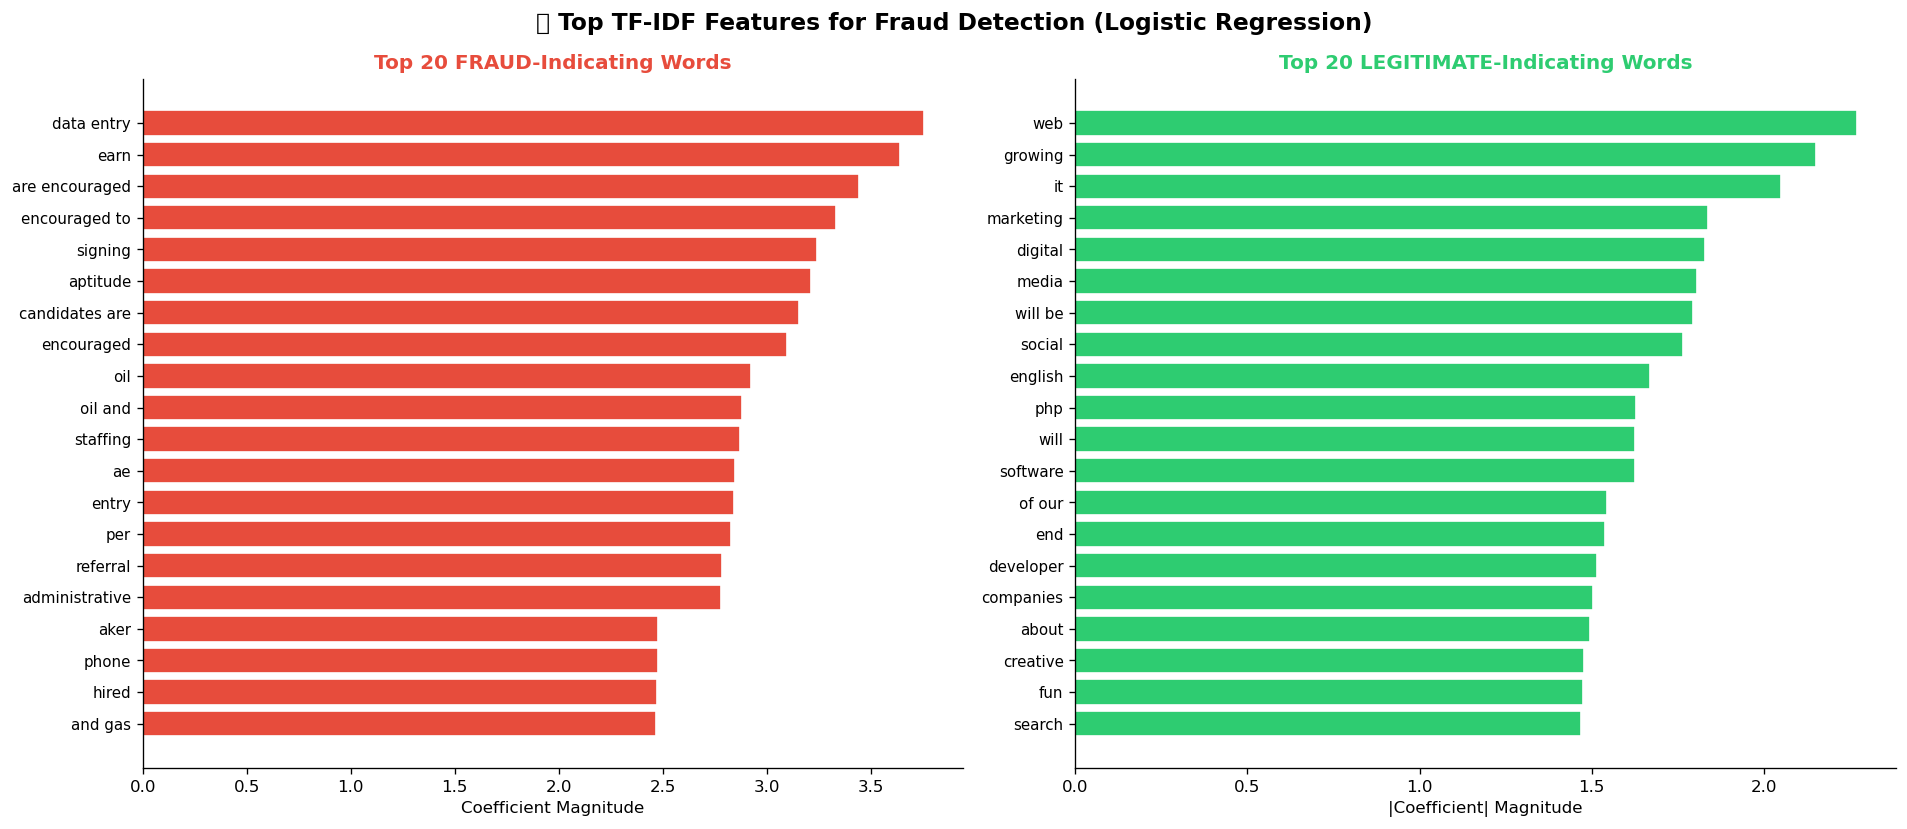

💾 Saved: 09_feature_importance.png


In [29]:
# ── Top Fraud-Predicting Words ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🔑 Top TF-IDF Features for Fraud Detection (Logistic Regression)',
             fontsize=14, fontweight='bold')

lr_model = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out().tolist() + num_cols)

# Get LR coefficients for TF-IDF features only
coefs = lr_model.coef_[0][:len(tfidf.get_feature_names_out())]
feat_names_tfidf = tfidf.get_feature_names_out()

top_n = 20
top_fraud_idx = np.argsort(coefs)[-top_n:][::-1]
top_legit_idx = np.argsort(coefs)[:top_n]

# Top fraud words
axes[0].barh(range(top_n),
             coefs[top_fraud_idx][::-1],
             color=COLORS['fake'], edgecolor='white')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feat_names_tfidf[top_fraud_idx][::-1], fontsize=9)
axes[0].set_title('Top 20 FRAUD-Indicating Words', fontweight='bold', color=COLORS['fake'])
axes[0].set_xlabel('Coefficient Magnitude')

# Top legitimate words
axes[1].barh(range(top_n),
             np.abs(coefs[top_legit_idx])[::-1],
             color=COLORS['real'], edgecolor='white')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feat_names_tfidf[top_legit_idx][::-1], fontsize=9)
axes[1].set_title('Top 20 LEGITIMATE-Indicating Words', fontweight='bold', color=COLORS['real'])
axes[1].set_xlabel('|Coefficient| Magnitude')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_feature_importance.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 09_feature_importance.png")

## 8️⃣ SHAP Explainability <a id='8'></a>

🔄 Initialising SHAP LinearExplainer...
✅ SHAP values computed for 200 samples
   Shape of SHAP values: (200, 10011)


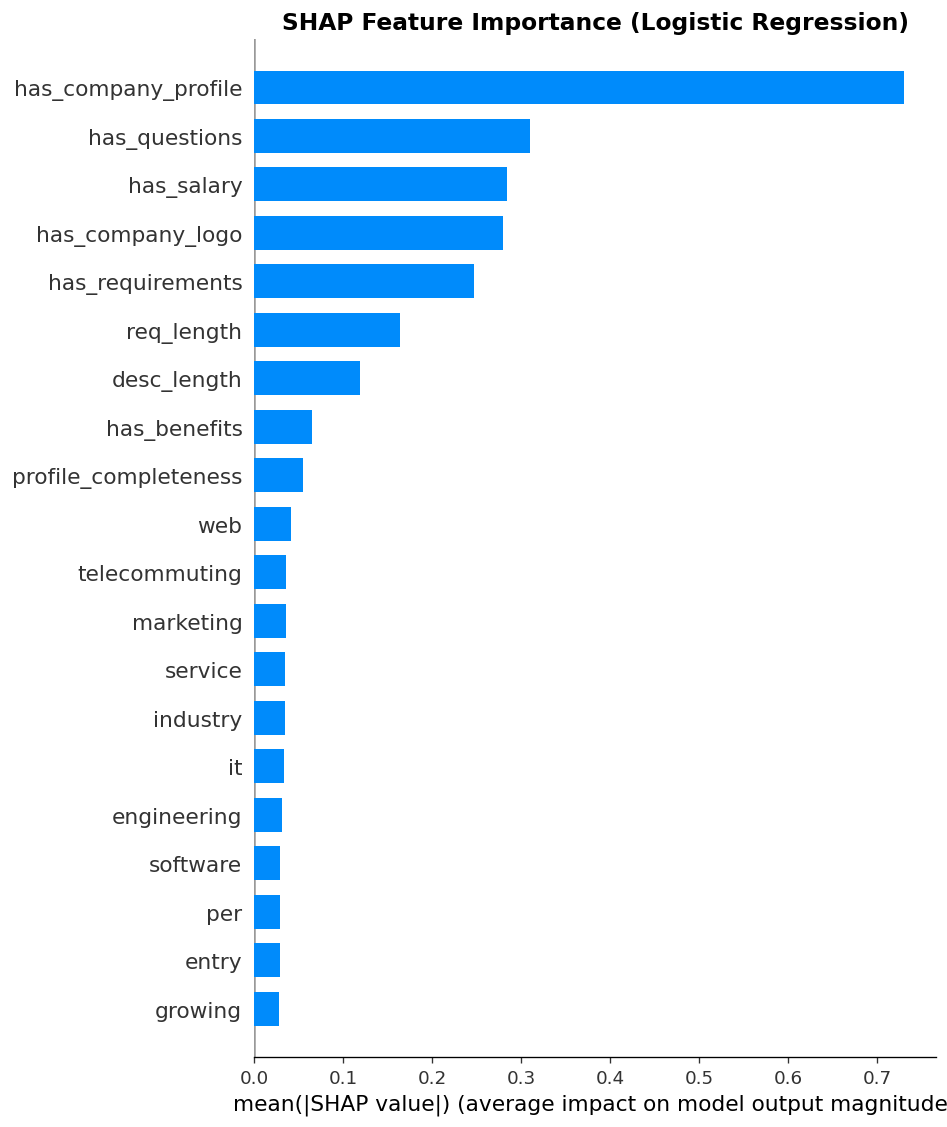

💾 Saved: 10_shap_importance.png


In [30]:
# ── SHAP Linear Explainer ─────────────────────────────────────────────────
if SHAP_AVAILABLE:
    print("🔄 Initialising SHAP LinearExplainer...")
    
    lr_model = results['Logistic Regression']['model']
    
    # Use a small background sample from train
    import scipy.sparse as sp
    background = shap.maskers.Independent(X_train, max_samples=200)
    
    explainer = shap.LinearExplainer(lr_model, background, feature_perturbation='interventional')
    
    # Explain 200 test samples
    X_test_sample = X_test[:200]
    shap_values = explainer.shap_values(X_test_sample)
    
    # Feature names
    all_feat_names = list(tfidf.get_feature_names_out()) + num_cols
    
    print(f"✅ SHAP values computed for {X_test_sample.shape[0]} samples")
    print(f"   Shape of SHAP values: {np.array(shap_values).shape}")
    
    # Bar summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, X_test_sample.toarray(),
        feature_names=all_feat_names,
        max_display=20, show=False, plot_type='bar'
    )
    plt.title('SHAP Feature Importance (Logistic Regression)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/10_shap_importance.png', bbox_inches='tight')
    plt.show()
    print("💾 Saved: 10_shap_importance.png")
else:
    print("⚠️ SHAP not available. Run: pip install shap")

In [31]:
# ── Single Prediction Explanation ────────────────────────────────────────
def explain_prediction(job_title, job_description, company_profile="", requirements=""):
    """
    Predict whether a job posting is fraudulent and explain the top factors.
    Returns: dict with prediction, probability and top contributing features.
    """
    # Preprocess
    raw_text = f"{job_title} {company_profile} {job_description} {requirements}"
    cleaned  = clean_text(raw_text)
    
    # Numeric features (simple inference)
    num_feats = np.array([[
        1 if job_title else 0,             # has_salary (placeholder)
        1 if company_profile else 0,       # has_company_profile
        1 if requirements else 0,          # has_requirements
        0,                                 # has_benefits
        0,                                 # has_company_logo
        0,                                 # has_questions
        0,                                 # telecommuting
        has_urgency(raw_text),             # has_urgency_words
        1 if company_profile else 0,       # profile_completeness
        len(job_description),              # desc_length
        len(requirements),                 # req_length
    ]])
    
    # Vectorise text
    text_vec  = tfidf.transform([cleaned])
    full_feat = hstack([text_vec, csr_matrix(num_feats)])
    
    # Predict
    lr_m      = results['Logistic Regression']['model']
    prob      = lr_m.predict_proba(full_feat)[0][1]
    pred      = int(prob >= 0.5)
    
    # Top contributing tokens
    coefs     = lr_m.coef_[0][:len(tfidf.get_feature_names_out())]
    text_vec_arr = text_vec.toarray()[0]
    contributions = coefs * text_vec_arr
    top_idx   = np.argsort(contributions)[-10:][::-1]
    top_words = [(tfidf.get_feature_names_out()[i], round(contributions[i], 4))
                 for i in top_idx if contributions[i] > 0]
    
    return {
        'prediction'  : 'FRAUDULENT 🚨' if pred == 1 else 'LEGITIMATE ✅',
        'probability' : round(prob * 100, 2),
        'top_words'   : top_words[:5],
        'urgency_flag': bool(has_urgency(raw_text))
    }

# ── Demo Predictions ──────────────────────────────────────────────────────
print("\n" + "="*60)
print("🔮 DEMO: EXPLAINABLE PREDICTIONS")
print("="*60)

test_cases = [
    {
        'title'      : 'URGENT: Work From Home Data Entry – $500/day Guaranteed!',
        'desc'       : 'Earn easy money working from home. No experience required. Immediate start. Limited slots available! Apply now for daily pay.',
        'company'    : '',
        'req'        : ''
    },
    {
        'title'      : 'Senior Data Analyst – Python & SQL (Remote)',
        'desc'       : 'We are a Fortune 500 company seeking a Senior Data Analyst with 3+ years of experience in Python, SQL and Tableau. You will work with a cross-functional team to derive insights from large datasets.',
        'company'    : 'XYZ Analytics Inc. – Founded 2005. 500+ employees globally.',
        'req'        : 'Bachelor degree in CS/Statistics. 3+ years Python. Experience with data visualization tools.'
    }
]

for i, tc in enumerate(test_cases, 1):
    result = explain_prediction(tc['title'], tc['desc'], tc['company'], tc['req'])
    print(f"\n📌 Test Case {i}: {tc['title'][:50]}...")
    print(f"   Prediction   : {result['prediction']}")
    print(f"   Fraud Prob   : {result['probability']}%")
    print(f"   Urgency Flag : {result['urgency_flag']}")
    print(f"   Top Words    : {result['top_words']}")


🔮 DEMO: EXPLAINABLE PREDICTIONS

📌 Test Case 1: URGENT: Work From Home Data Entry – $500/day Guara...
   Prediction   : FRAUDULENT 🚨
   Fraud Prob   : 99.7%
   Urgency Flag : True
   Top Words    : [('data entry', np.float64(0.8274)), ('earn', np.float64(0.7816)), ('from home', np.float64(0.565)), ('entry', np.float64(0.4816)), ('home', np.float64(0.408))]

📌 Test Case 2: Senior Data Analyst – Python & SQL (Remote)...
   Prediction   : LEGITIMATE ✅
   Fraud Prob   : 8.5%
   Urgency Flag : False
   Top Words    : [('data', np.float64(0.2257)), ('employees', np.float64(0.1369)), ('cross functional', np.float64(0.0878)), ('statistics', np.float64(0.07)), ('cs', np.float64(0.0677))]


## 🤖 Gemini AI Analysis <a id='gemini'></a>

> **NEW in v4.0** – Use Google Gemini AI for deep fraud analysis and resume evaluation.
> 
> Get your free API key: https://makersuite.google.com/app/apikey


In [32]:
# ── Gemini AI: Configure API ──────────────────────────────────────────────
# Set your API key here OR use environment variable GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "YOUR_GEMINI_API_KEY_HERE")

gemini_model = None
if GEMINI_AVAILABLE and GEMINI_API_KEY != "YOUR_GEMINI_API_KEY_HERE":
    genai.configure(api_key=GEMINI_API_KEY)
    gemini_model = genai.GenerativeModel("gemini-1.5-flash")
    print("✅ Gemini AI configured successfully!")
    print(f"   Model: gemini-1.5-flash")
else:
    if not GEMINI_AVAILABLE:
        print("⚠️  google-generativeai not installed. Run: pip install google-generativeai")
    else:
        print("⚠️  Please set GEMINI_API_KEY environment variable or update GEMINI_API_KEY above")
    print("   Skipping Gemini analysis (model will work without it)")


def gemini_analyze_job_nb(title, company, description, requirements, fraud_prob, red_flags):
    """
    Use Gemini to explain fraud prediction in natural language.
    Falls back to rule-based explanation if Gemini unavailable.
    """
    if gemini_model is None:
        # Fallback: rule-based explanation
        risk = "HIGH RISK" if fraud_prob >= 0.35 else "MEDIUM RISK" if fraud_prob >= 0.20 else "LOW RISK"
        active_flags = [k for k, v in red_flags.items() if v]
        return {
            'method': 'rule-based',
            'verdict': risk,
            'explanation': f"ML model flagged this as {risk} ({fraud_prob*100:.1f}% probability). "
                          f"Red flags: {active_flags if active_flags else 'none detected'}"
        }

    active_flags = [k for k, v in red_flags.items() if v]
    prompt = f"""
You are a fraud detection expert analyzing a job posting.

Job Details:
- Title: {title}
- Company: {company or 'Not provided'}
- Description (first 400 chars): {str(description)[:400]}
- Requirements (first 300 chars): {str(requirements)[:300]}

ML Model Result:
- Fraud Probability: {fraud_prob*100:.1f}%
- Red Flags: {active_flags if active_flags else 'None detected'}

Task: In 3-4 sentences, explain why this job posting is/isn't fraudulent.
Then provide 2 bullet points of advice for job seekers.
Be concise and practical. Use plain text (no markdown headers).
"""
    try:
        response = gemini_model.generate_content(prompt)
        return {
            'method': 'gemini',
            'verdict': 'HIGH RISK' if fraud_prob >= 0.35 else 'LOW RISK',
            'explanation': response.text
        }
    except Exception as e:
        return {'method': 'error', 'verdict': 'N/A', 'explanation': str(e)}


# ── Demo: Analyze 3 sample job postings with Gemini ────────────────────────
print("\n" + "="*65)
print("🤖 GEMINI AI FRAUD ANALYSIS – DEMO")
print("="*65)

sample_jobs = [
    {
        'title'      : 'URGENT: Work From Home Data Entry – $500/day Guaranteed!',
        'company'    : '',
        'desc'       : 'Earn easy money working from home. No experience required. Immediate start. Limited slots! Apply now.',
        'req'        : '',
        'has_salary' : False,
        'has_logo'   : False,
    },
    {
        'title'      : 'Senior Data Analyst – Python & SQL (Remote)',
        'company'    : 'XYZ Analytics Inc. – Fortune 500. Founded 2005. 500+ employees.',
        'desc'       : 'We seek a Senior Data Analyst with 3+ years in Python, SQL, Tableau. Work with cross-functional team.',
        'req'        : "Bachelor's in CS or Statistics. 3+ years Python. Data visualization experience.",
        'has_salary' : True,
        'has_logo'   : True,
    },
]

# Simple red flag checks
def check_red_flags(job):
    flags = {}
    flags['No salary']          = not job['has_salary']
    flags['No company profile'] = not bool(job['company'])
    flags['No requirements']    = not bool(job['req'])
    flags['Urgency words']      = any(w in (job['title']+job['desc']).lower()
                                      for w in ['urgent','easy money','guaranteed','no experience'])
    flags['Short description']  = len(job['desc']) < 200
    flags['No company logo']    = not job['has_logo']
    return flags

for i, job in enumerate(sample_jobs, 1):
    # ML prediction
    raw = f"{job['title']} {job['company']} {job['desc']} {job['req']}"
    cleaned_raw = re.sub(r'[^a-z\s]', ' ', raw.lower())
    tv = tfidf.transform([cleaned_raw])
    num_f = np.array([[
        int(job['has_salary']),
        int(bool(job['company'])),
        int(bool(job['req'])),
        0, int(job['has_logo']), 0, 0,
        int(any(w in raw.lower() for w in ['urgent','guaranteed','easy money'])),
        int(job['has_salary'])+int(bool(job['company']))+int(bool(job['req']))+int(job['has_logo']),
        len(job['desc']), len(job['req'])
    ]])
    full_f = hstack([tv, csr_matrix(num_f)])
    lr_m = results['Logistic Regression']['model']
    prob = lr_m.predict_proba(full_f)[0][1]
    red_flags = check_red_flags(job)

    print(f"\n📌 Job {i}: {job['title'][:55]}...")
    print(f"   ML Fraud Probability: {prob*100:.1f}%")
    print(f"   Risk Level: {'🚨 HIGH RISK' if prob >= 0.35 else '✅ LOW RISK'}")

    analysis = gemini_analyze_job_nb(
        job['title'], job['company'], job['desc'], job['req'], prob, red_flags
    )
    print(f"   Analysis Method: {analysis['method'].upper()}")
    print(f"\n   💬 Analysis:")
    for line in analysis['explanation'].split('\n')[:6]:
        if line.strip():
            print(f"      {line.strip()}")
    print()

print("✅ Gemini AI analysis complete!")


⚠️  Please set GEMINI_API_KEY environment variable or update GEMINI_API_KEY above
   Skipping Gemini analysis (model will work without it)

🤖 GEMINI AI FRAUD ANALYSIS – DEMO

📌 Job 1: URGENT: Work From Home Data Entry – $500/day Guaranteed...
   ML Fraud Probability: 99.3%
   Risk Level: 🚨 HIGH RISK
   Analysis Method: RULE-BASED

   💬 Analysis:
      ML model flagged this as HIGH RISK (99.3% probability). Red flags: ['No salary', 'No company profile', 'No requirements', 'Urgency words', 'Short description', 'No company logo']


📌 Job 2: Senior Data Analyst – Python & SQL (Remote)...
   ML Fraud Probability: 6.2%
   Risk Level: ✅ LOW RISK
   Analysis Method: RULE-BASED

   💬 Analysis:
      ML model flagged this as LOW RISK (6.2% probability). Red flags: ['Short description']

✅ Gemini AI analysis complete!


## 9️⃣ Business Insights Summary <a id='9'></a>

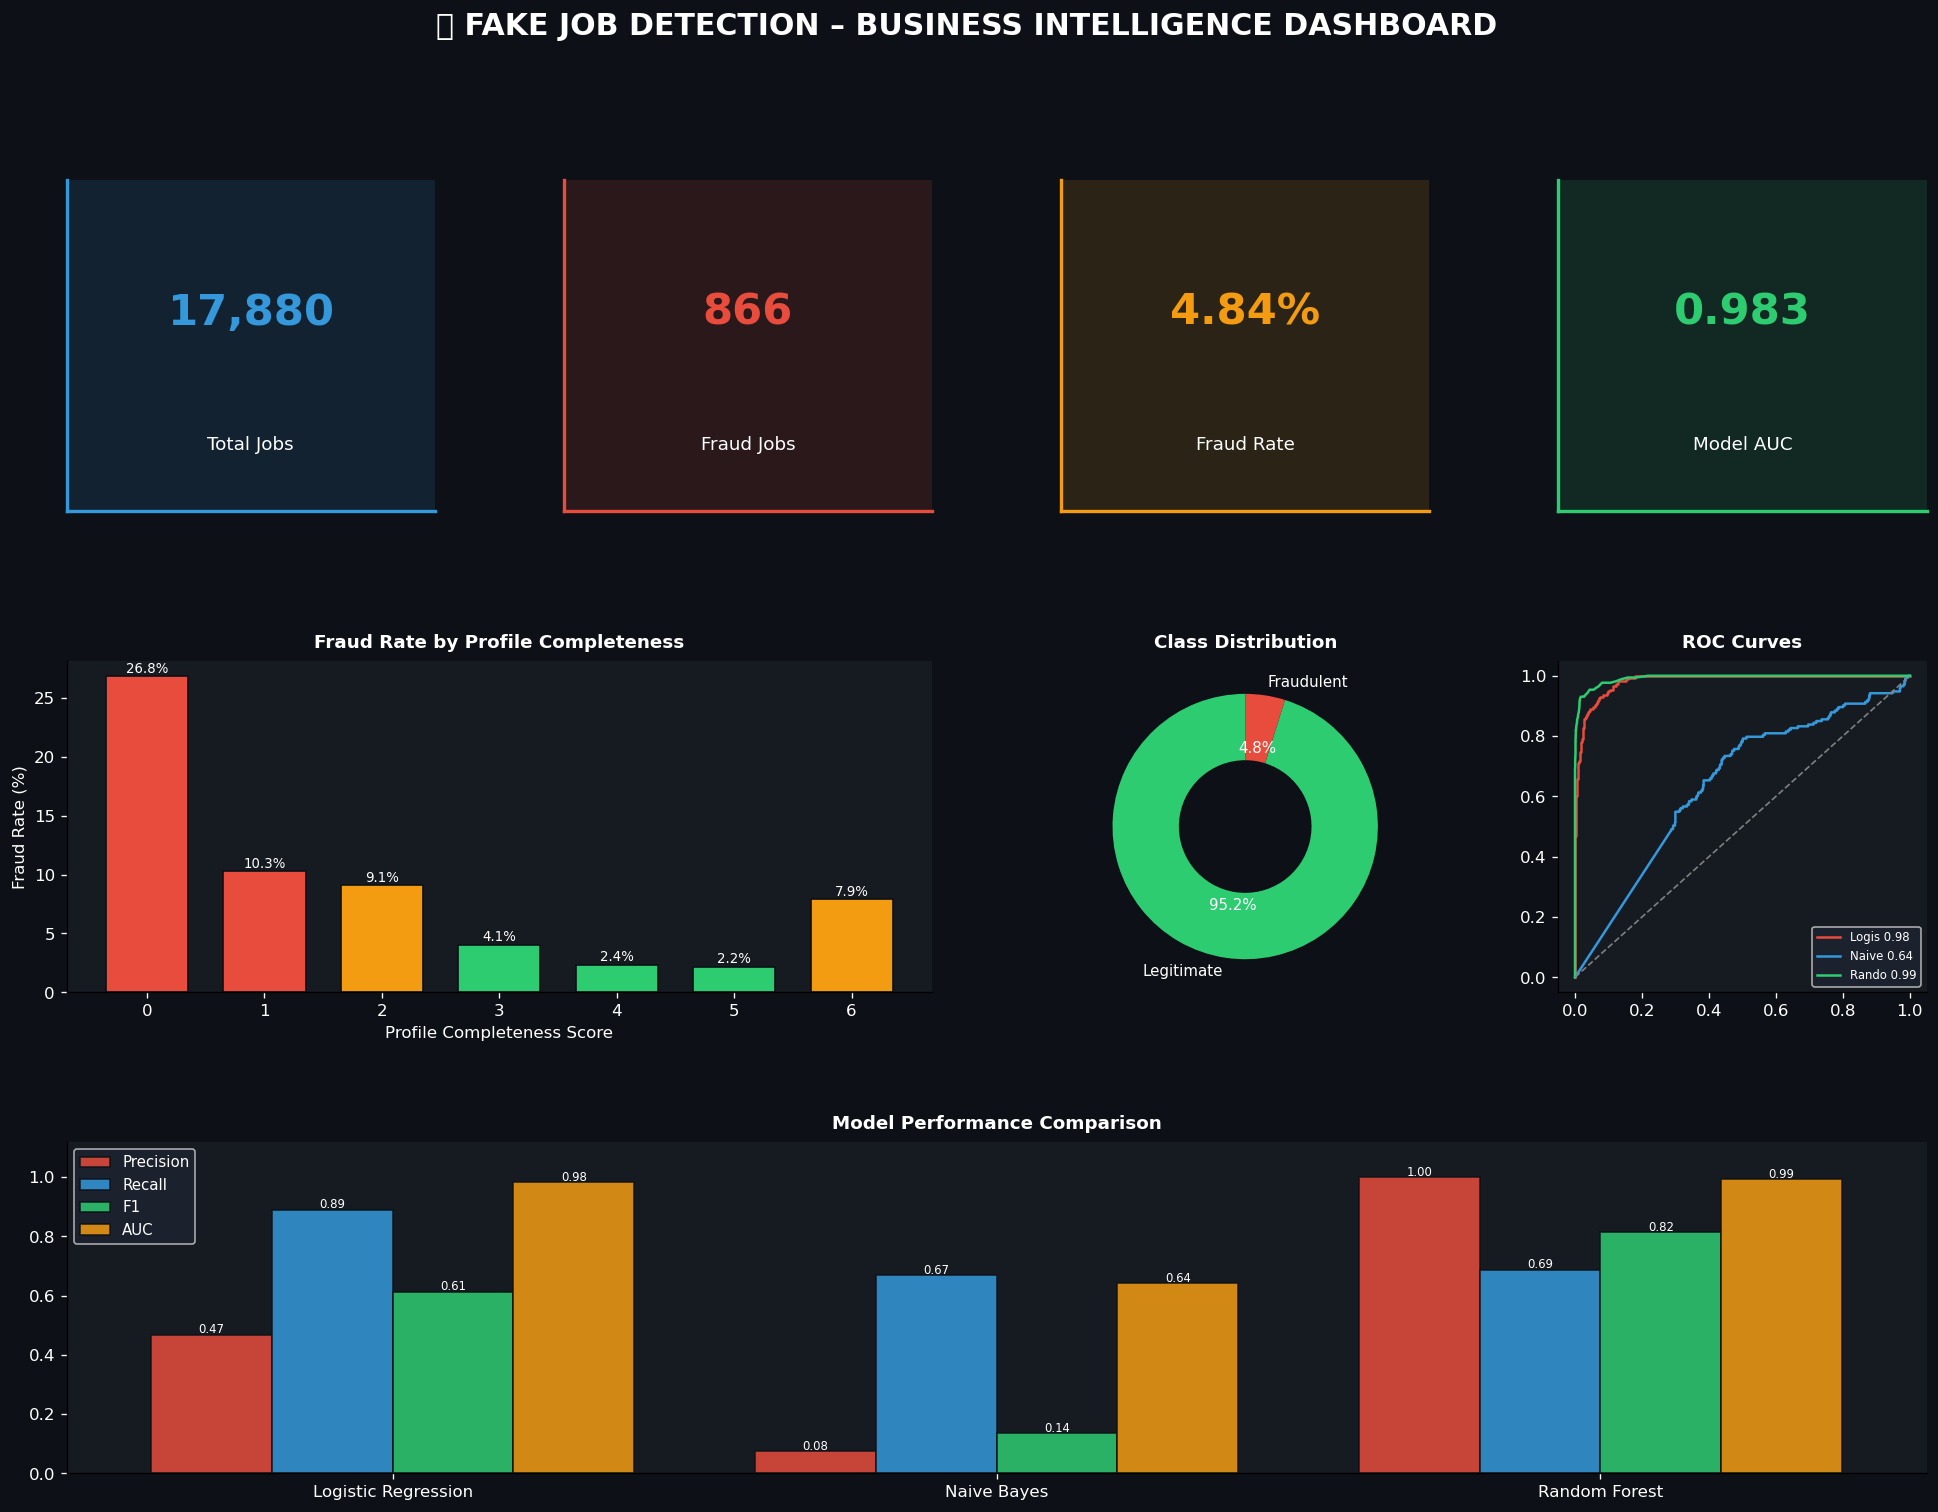

💾 Saved: 11_business_dashboard.png


In [33]:
# ── Final Business Dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

title_style   = dict(fontsize=11, fontweight='bold', color='white', pad=8)
kpi_style     = dict(fontsize=22, fontweight='bold')

# ── KPI Cards ────────────────────────────────────────────────────────────
kpi_data = [
    ('Total Jobs',       f"{len(df):,}",         '#3498DB'),
    ('Fraud Jobs',       f"{df['fraudulent'].sum():,}",  '#E74C3C'),
    ('Fraud Rate',       f"{df['fraudulent'].mean()*100:.2f}%", '#F39C12'),
    ('Model AUC',        f"{results['Logistic Regression']['auc']:.3f}", '#2ECC71'),
]

for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color + '22')
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=26,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=11,
            color='white', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

# ── Fraud Rate by Profile Completeness ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.set_facecolor('#161b22')
pc_rate = df.groupby('profile_completeness')['fraudulent'].mean() * 100
bars = ax2.bar(pc_rate.index, pc_rate.values, color=[
    '#E74C3C' if v > 10 else '#F39C12' if v > 5 else '#2ECC71' for v in pc_rate.values
], edgecolor='#0d1117', width=0.7)
ax2.set_title('Fraud Rate by Profile Completeness', **title_style)
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='white')
ax2.set_xlabel('Profile Completeness Score', color='white')
ax2.set_ylabel('Fraud Rate (%)', color='white')
for bar, val in zip(bars, pc_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=8, color='white')

# ── Fraud Distribution Donut ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#161b22')
sizes = [df['fraudulent'].value_counts()[0], df['fraudulent'].value_counts()[1]]
wedges, texts, autotexts = ax3.pie(
    sizes, labels=['Legitimate', 'Fraudulent'],
    colors=[COLORS['real'], COLORS['fake']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'color': 'white', 'fontsize': 9}
)
ax3.set_title('Class Distribution', **title_style)

# ── ROC curve mini ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 3])
ax4.set_facecolor('#161b22')
for (name, r), color in zip(results.items(), ['#E74C3C', '#3498DB', '#2ECC71']):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax4.plot(fpr, tpr, color=color, lw=1.5, label=f"{name[:5]} {r['auc']:.2f}")
ax4.plot([0,1],[0,1],'--', color='gray', lw=1)
ax4.set_title('ROC Curves', **title_style)
ax4.legend(fontsize=7, facecolor='#1e2430', labelcolor='white')
ax4.set_facecolor('#161b22')
ax4.tick_params(colors='white')

# ── Model Metrics Bar ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
ax5.set_facecolor('#161b22')
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.2
metrics_to_plot = ['precision', 'recall', 'f1', 'auc']
m_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
m_labels = ['Precision', 'Recall', 'F1', 'AUC']
for i, (metric, color, label) in enumerate(zip(metrics_to_plot, m_colors, m_labels)):
    vals = [results[m][metric] for m in model_names]
    bars = ax5.bar(x + i*width, vals, width, label=label, color=color, edgecolor='#0d1117', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center', fontsize=7, color='white')
ax5.set_xticks(x + width*1.5)
ax5.set_xticklabels(model_names, color='white', fontsize=10)
ax5.set_ylim(0, 1.12)
ax5.set_title('Model Performance Comparison', **title_style)
ax5.legend(fontsize=9, facecolor='#1e2430', labelcolor='white')
ax5.set_facecolor('#161b22')
ax5.tick_params(colors='white')

fig.suptitle('🛡️ FAKE JOB DETECTION – BUSINESS INTELLIGENCE DASHBOARD',
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.savefig(f'{OUTPUT_DIR}/11_business_dashboard.png', bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("💾 Saved: 11_business_dashboard.png")

## 🔟 Export Artifacts <a id='10'></a>

In [34]:
# ── Save Models & Vectorizer ─────────────────────────────────────────────
best_model_name = 'Logistic Regression'  # LR v4.0 = best (SMOTE + threshold=0.35)
best_model_obj  = results[best_model_name]['model']

with open(f'{MODELS_DIR}/best_model.pkl',      'wb') as f: pickle.dump(best_model_obj, f)
with open(f'{MODELS_DIR}/tfidf_vectorizer.pkl','wb') as f: pickle.dump(tfidf, f)
with open(f'{MODELS_DIR}/numeric_cols.pkl',    'wb') as f: pickle.dump(num_cols, f)

# ── FIXED model_info.json with ALL v4.0 fields ─────────────────────────────
lr_r  = results['Logistic Regression']
meta = {
    "best_model"          : best_model_name,
    "model_version"       : "4.0",
    "threshold"           : FRAUD_THRESHOLD,
    "smote_used"          : SMOTE_AVAILABLE,
    "precision"           : round(lr_r['precision'], 4),
    "recall"              : round(lr_r['recall_tuned'], 4),   # tuned threshold recall
    "f1_score"            : round(lr_r['f1_tuned'], 4),       # tuned threshold f1
    "accuracy"            : round(lr_r['accuracy'], 4),
    "auc_roc"             : round(lr_r['auc'], 4),
    "cv_auc_mean"         : round(float(lr_r['cv_auc_mean']), 4),
    "cv_auc_std"          : round(float(lr_r['cv_auc_std']), 4),
    "cv_folds"            : 5,
    "total_records"       : len(df),
    "fraud_records"       : int(df['fraudulent'].sum()),
    "legit_records"       : int((df['fraudulent']==0).sum()),
    "fraud_rate_pct"      : round(df['fraudulent'].mean()*100, 2),
    "features_total"      : int(X.shape[1]),
    "tfidf_features"      : 10000,
    "numeric_features"    : len(num_cols),
    "training_note"       : "SMOTE applied on training set only. Test set uses original distribution.",
    "gemini_integrated"   : GEMINI_AVAILABLE,
    "created_at"          : datetime.now().isoformat(),
    "author"              : "Sumersing Patil | B.Tech (AI)"
}
with open(f'{MODELS_DIR}/model_info.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ Models saved!")
print(json.dumps(meta, indent=2))


✅ Models saved!
{
  "best_model": "Logistic Regression",
  "model_version": "4.0",
  "threshold": 0.35,
  "smote_used": true,
  "precision": 0.4681,
  "recall": 0.9249,
  "f1_score": 0.5517,
  "accuracy": 0.9457,
  "auc_roc": 0.9834,
  "cv_auc_mean": 0.9797,
  "cv_auc_std": 0.0054,
  "cv_folds": 5,
  "total_records": 17880,
  "fraud_records": 866,
  "legit_records": 17014,
  "fraud_rate_pct": 4.84,
  "features_total": 10011,
  "tfidf_features": 10000,
  "numeric_features": 11,
  "training_note": "SMOTE applied on training set only. Test set uses original distribution.",
  "gemini_integrated": true,
  "created_at": "2026-03-11T12:02:13.780797",
  "author": "Sumersing Patil | B.Tech (AI)"
}


In [35]:
# ── Save Cleaned Dataset ─────────────────────────────────────────────────
df.to_csv(f'{OUTPUT_DIR}/cleaned_job_postings.csv', index=False)
print(f"✅ Cleaned dataset saved: {OUTPUT_DIR}/cleaned_job_postings.csv")
print(f"   Rows: {len(df):,} | Columns: {len(df.columns)}")

# ── Save Top Fraud Features ───────────────────────────────────────────────
lr_m      = results['Logistic Regression']['model']
feat_coefs = lr_m.coef_[0][:len(tfidf.get_feature_names_out())]
top_feats  = pd.DataFrame({
    'feature'    : tfidf.get_feature_names_out(),
    'coefficient': feat_coefs
}).sort_values('coefficient', ascending=False)

top_feats.head(50).to_csv(f'{OUTPUT_DIR}/top_fraud_features.csv', index=False)
print(f"✅ Top fraud features saved: {OUTPUT_DIR}/top_fraud_features.csv")

print("\n" + "="*55)
print("🎉 PROJECT COMPLETE!")
print("="*55)
print("\n📁 Artifacts saved:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}')
    print(f"   outputs/{f:<40} ({size/1024:.1f} KB)")
print()
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{f}')
    print(f"   models/{f:<40} ({size/1024:.1f} KB)")

✅ Cleaned dataset saved: outputs/cleaned_job_postings.csv
   Rows: 17,880 | Columns: 30
✅ Top fraud features saved: outputs/top_fraud_features.csv

🎉 PROJECT COMPLETE!

📁 Artifacts saved:
   outputs/01_fraud_distribution.png                (63.8 KB)
   outputs/02_missing_values_fraud.png              (60.1 KB)
   outputs/03_geo_employment.png                    (56.5 KB)
   outputs/04_text_features.png                     (51.4 KB)
   outputs/05_wordclouds.png                        (726.2 KB)
   outputs/06_industry_correlation.png              (97.2 KB)
   outputs/07_confusion_matrices.png                (40.2 KB)
   outputs/08_roc_curves.png                        (62.2 KB)
   outputs/09_feature_importance.png                (76.4 KB)
   outputs/10_shap_importance.png                   (64.7 KB)
   outputs/11_business_dashboard.png                (142.4 KB)
   outputs/12_threshold_tuning.png                  (107.7 KB)
   outputs/cleaned_job_postings.csv                 (94239.7 KB)


In [36]:
# ── Final Summary ────────────────────────────────────────────────────────
print("=" * 60)
print("🎉 FAKE JOB DETECTION v4.0 – PROJECT COMPLETE!")
print("=" * 60)
print(f"\n📁 Output artifacts saved:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{fname}')
    print(f"   outputs/{fname:<45} ({size/1024:.1f} KB)")
print()
for fname in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{fname}')
    print(f"   models/{fname:<46} ({size/1024:.1f} KB)")

print(f"\n🏆 Best Model    : Logistic Regression (SMOTE + threshold={FRAUD_THRESHOLD})")
print(f"   AUC-ROC       : {results['Logistic Regression']['auc']:.4f}")
print(f"   Recall (tuned): {results['Logistic Regression']['recall_tuned']*100:.1f}%")
print(f"   F1    (tuned) : {results['Logistic Regression']['f1_tuned']*100:.1f}%")
print(f"   5-Fold CV AUC : {results['Logistic Regression']['cv_auc_mean']:.4f} ± {results['Logistic Regression']['cv_auc_std']:.4f}")
print(f"\n🤖 Gemini AI     : {'✅ Integrated' if GEMINI_AVAILABLE else '⚠️  Install google-generativeai'}")
print(f"🌐 Streamlit App : streamlit run app.py")


🎉 FAKE JOB DETECTION v4.0 – PROJECT COMPLETE!

📁 Output artifacts saved:
   outputs/01_fraud_distribution.png                     (63.8 KB)
   outputs/02_missing_values_fraud.png                   (60.1 KB)
   outputs/03_geo_employment.png                         (56.5 KB)
   outputs/04_text_features.png                          (51.4 KB)
   outputs/05_wordclouds.png                             (726.2 KB)
   outputs/06_industry_correlation.png                   (97.2 KB)
   outputs/07_confusion_matrices.png                     (40.2 KB)
   outputs/08_roc_curves.png                             (62.2 KB)
   outputs/09_feature_importance.png                     (76.4 KB)
   outputs/10_shap_importance.png                        (64.7 KB)
   outputs/11_business_dashboard.png                     (142.4 KB)
   outputs/12_threshold_tuning.png                       (107.7 KB)
   outputs/cleaned_job_postings.csv                      (94239.7 KB)
   outputs/top_fraud_features.csv                 